<a href="https://colab.research.google.com/github/jenny005/geo-koopman/blob/main/GeoKoop_v4_fixed_(4).ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# GeoKoop — Multi-System Experiments
## Four-Model Comparison + Mechanism Test: N(z) ≈ J_f(z) - K

Systems: Pendulum · FluidFlowBox · Cylinder · Van der Pol · Lorenz · Kuramoto-Sivashinsky

**Table 3**: Four-model comparison (5 seeds) — Pendulum, FluidFlowBox, Cylinder  
**Table 4**: Mechanism test N(z)≈J_f(z)-K — all six systems
**Before running:** `Runtime > Change runtime type > T4 GPU > Save`

Four models compared across Pendulum, FluidFlowBox, and Cylinder:

| # | Model | Dynamics | Role |
|---|-------|----------|------|
| 1 | **Classical Koopman / DMD** | fixed linear in observation space | analytic baseline |
| 2 | **Black-box NN** | `z_{t+1} = f_theta(z_t)`, unconstrained MLP | expressiveness upper bound |
| 3 | **Deep Koopman** | `z_{t+1} = K z_t`, learned encoder | structured linear baseline |
| 4 | **GeoKoop (proposed)** | `z_{t+1} = (K + N(z_t)) z_t` | geometry-aware |

**Curvature experiment** (Cells A–E) runs automatically after each system's training.
Key result: κ(G(z_t)) in the latent space predicts where Euclidean rollouts fail,
and the geo-aware model suppresses this curvature growth.

$$z_{t+1} = \underbrace{K z_t}_{\text{linear}} + \underbrace{N(z_t)z_t}_{\text{curvature correction}}$$

$$G(z) = J_D(z)^\top J_D(z), \quad \kappa(G) = \lambda_{\max}/\lambda_{\min}$$


In [7]:
# ── Cell 1: Setup ─────────────────────────────────────────────────
from google.colab import drive
drive.mount('/content/drive')

import numpy as np
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
import scipy.io
import os, shutil

device = 'cuda' if torch.cuda.is_available() else 'cpu'
print(f'PyTorch {torch.__version__}')
print(f'Device: {device}')
if torch.cuda.is_available():
    print(f'GPU: {torch.cuda.get_device_name(0)}')
else:
    print('WARNING: No GPU — Runtime > Change runtime type > T4 GPU')


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
PyTorch 2.11.0+cu128
Device: cuda
GPU: Tesla T4


In [8]:
BASE_DIR = "/content/drive/MyDrive/Koopman"

DATA_DIR = f"{BASE_DIR}/DeepKoopman_data/data"
CYLINDER = f"{BASE_DIR}/Cylinder_data/DATA/FLUIDS/CYLINDER_ALL.mat"


OUTPUT_DIR = f"{BASE_DIR}/outputs"
FIG_DIR    = f"{OUTPUT_DIR}/figures"
MODEL_DIR  = f"{OUTPUT_DIR}/models"
LOG_DIR    = f"{OUTPUT_DIR}/logs"
# ── Create output directories ──────────────────────────────────
for d in [OUTPUT_DIR, FIG_DIR, MODEL_DIR, LOG_DIR]:
    os.makedirs(d, exist_ok=True)
print(f'Output dirs ready under: {OUTPUT_DIR}')


Output dirs ready under: /content/drive/MyDrive/Koopman/outputs


In [9]:
# Cell 3: Shared model definitions — four models

# ── Autoencoder ────────────────────────────────────────────────
class AE(nn.Module):
    """Encoder-decoder with configurable hidden width."""
    def __init__(self, input_dim, latent_dim, hidden=128):
        super().__init__()
        self.encoder = nn.Sequential(
            nn.Linear(input_dim, hidden), nn.Tanh(),
            nn.Linear(hidden, hidden//2),  nn.Tanh(),
            nn.Linear(hidden//2, latent_dim),
        )
        self.decoder = nn.Sequential(
            nn.Linear(latent_dim, hidden//2), nn.Tanh(),
            nn.Linear(hidden//2, hidden),      nn.Tanh(),
            nn.Linear(hidden, input_dim),
        )
    def encode(self, x): return self.encoder(x)
    def decode(self, z): return self.decoder(z)


# ── Model 2: Black-box NN ──────────────────────────────────────
class BlackBoxNN(nn.Module):
    """
    Unconstrained latent dynamics: z_{t+1} = f_theta(z_t).
    Same parameter budget as KoopmanCore (hidden=64) for a fair comparison.
    No K matrix, no spectral constraint, no geo regulariser.
    """
    def __init__(self, latent_dim, hidden=64):
        super().__init__()
        self.f = nn.Sequential(
            nn.Linear(latent_dim, hidden), nn.Tanh(),
            nn.Linear(hidden, hidden),     nn.Tanh(),
            nn.Linear(hidden, latent_dim),
        )
    def forward(self, z): return self.f(z)


# ── Model 3 & 4: KoopmanCore ───────────────────────────────────
class KoopmanCore(nn.Module):
    """
    use_geo=False  ->  Deep Koopman:  z_{t+1} = K z_t
    use_geo=True   ->  GeoKoop:       z_{t+1} = (K + N(z_t)) z_t
    """
    def __init__(self, latent_dim, K_init=None, eps=1.0, use_geo=True):
        super().__init__()
        self.d = latent_dim; self.eps = eps; self.use_geo = use_geo
        if K_init is not None:
            K_arr = np.array(K_init, dtype=np.float32)
            K0 = torch.tensor(K_arr[:latent_dim, :latent_dim],
                              dtype=torch.float32)
        else:
            K0 = torch.eye(latent_dim)
        self.K = nn.Parameter(K0)
        if use_geo:
            self.N_net = nn.Sequential(
                nn.Linear(latent_dim, 64), nn.Tanh(),
                nn.Linear(64, 64),         nn.Tanh(),
                nn.Linear(64, latent_dim * latent_dim),
            )
            nn.init.zeros_(self.N_net[-1].weight)
            nn.init.zeros_(self.N_net[-1].bias)

    def forward(self, z):
        z_lin = z @ self.K.T
        if self.use_geo:
            B = z.shape[0]
            N = self.N_net(z).view(B, self.d, self.d)
            return z_lin + self.eps * torch.bmm(N, z.unsqueeze(-1)).squeeze(-1)
        return z_lin

    def geo_loss(self, z):
        if not self.use_geo: return torch.tensor(0., device=z.device)
        N = self.N_net(z).view(z.shape[0], self.d * self.d)
        return torch.mean(torch.norm(N, dim=1))


# ── Shared utilities ────────────────────────────────────────────
def spectral_penalty(K):
    ev = torch.linalg.eigvals(K.unsqueeze(0))
    return ((ev.abs() - 1.0) ** 2).mean()


def dmd_matrix(X, rank=20):
    """DMD operator from data matrix X (n_features, T)."""
    X1 = X[:, :-1]; X2 = X[:, 1:]
    U_, S_, Vt_ = np.linalg.svd(X1, full_matrices=False)
    rank = min(rank, int((S_ > 1e-10 * S_[0]).sum()))
    Ur = U_[:, :rank]; Vr = Vt_[:rank].T; Sr_inv = np.diag(1.0 / S_[:rank])
    return Ur @ (Ur.T @ X2 @ Vr @ Sr_inv) @ Ur.T


# ── Model 3/4 training loop ─────────────────────────────────────
def train_model(ae, koopman, x_t, x_tp1, use_geo, label,
                epochs_p1=500, epochs_p2=3000,
                rollout_steps=20, lam_geo=0.0,
                lr_ae=1e-3, lr_K=5e-5, lr_N=5e-4):
    params = [{'params': ae.parameters(), 'lr': lr_ae},
              {'params': [koopman.K],     'lr': lr_K}]
    if use_geo:
        params.append({'params': koopman.N_net.parameters(), 'lr': lr_N})
    opt = torch.optim.Adam(params)
    sch = torch.optim.lr_scheduler.StepLR(opt, step_size=1000, gamma=0.5)

    for epoch in range(epochs_p1 + epochs_p2):
        ae.train(); koopman.train(); opt.zero_grad()
        z = ae.encode(x_t); z_nxt = ae.encode(x_tp1)
        loss_rec  = ((ae.decode(z) - x_t)**2).mean()
        loss_dyn  = ((koopman(z) - z_nxt)**2).mean()
        loss_spec = spectral_penalty(koopman.K)
        loss_roll = torch.tensor(0., device=device)
        if epoch >= epochs_p1 and rollout_steps > 0:
            n = x_t.shape[0] - rollout_steps
            zr = ae.encode(x_t[:n]).detach()
            for k in range(rollout_steps):
                zr = koopman(zr)
                zt = ae.encode(x_t[k+1:k+1+n]).detach()
                loss_roll += ((zr - zt)**2).mean()
            loss_roll = torch.clamp(loss_roll / rollout_steps, max=5.0)
        loss_geo = koopman.geo_loss(z)
        loss = (loss_rec + 0.1*loss_dyn + 0.01*loss_spec + lam_geo*loss_geo) \
               if epoch < epochs_p1 else \
               (loss_rec + 1.0*loss_dyn + 0.5*loss_roll + 0.01*loss_spec + lam_geo*loss_geo)
        loss.backward()
        nn.utils.clip_grad_norm_(list(ae.parameters()) + list(koopman.parameters()), 0.5)
        opt.step(); sch.step()
        if epoch % 200 == 0:
            print(f'[{label}] {epoch:4d} | rec={loss_rec.item():.5f} '
                  f'dyn={loss_dyn.item():.5f} roll={loss_roll.item():.5f} '
                  f'geo={loss_geo.item():.4f}')


# ── Model 2 (Black-box NN) training loop ────────────────────────
def train_blackbox(ae, bb, x_t, x_tp1, label,
                   epochs_p1=500, epochs_p2=3000,
                   rollout_steps=20,
                   lr_ae=1e-3, lr_f=1e-3):
    """
    Two-phase training mirroring KoopmanCore for a fair comparison.
    No spectral penalty (no K), no geo regulariser.
    """
    opt = torch.optim.Adam(
        list(ae.parameters()) + list(bb.parameters()),
        lr=lr_ae)
    sch = torch.optim.lr_scheduler.StepLR(opt, step_size=1000, gamma=0.5)

    for epoch in range(epochs_p1 + epochs_p2):
        ae.train(); bb.train(); opt.zero_grad()
        z = ae.encode(x_t); z_nxt = ae.encode(x_tp1)
        loss_rec = ((ae.decode(z) - x_t)**2).mean()
        loss_dyn = ((bb(z) - z_nxt)**2).mean()
        loss_roll = torch.tensor(0., device=device)
        if epoch >= epochs_p1 and rollout_steps > 0:
            n = x_t.shape[0] - rollout_steps
            zr = ae.encode(x_t[:n]).detach()
            for k in range(rollout_steps):
                zr = bb(zr)
                zt = ae.encode(x_t[k+1:k+1+n]).detach()
                loss_roll += ((zr - zt)**2).mean()
            loss_roll = torch.clamp(loss_roll / rollout_steps, max=5.0)
        loss = (loss_rec + 0.1*loss_dyn) if epoch < epochs_p1 else \
               (loss_rec + 1.0*loss_dyn + 0.5*loss_roll)
        loss.backward()
        nn.utils.clip_grad_norm_(
            list(ae.parameters()) + list(bb.parameters()), 0.5)
        opt.step(); sch.step()
        if epoch % 200 == 0:
            print(f'[{label}] {epoch:4d} | rec={loss_rec.item():.5f} '
                  f'dyn={loss_dyn.item():.5f} roll={loss_roll.item():.5f}')


# ── Rollout evaluation (same for all AE-based models) ───────────
@torch.no_grad()
def rollout_error(ae, dyn, X_data, steps=49):
    ae.eval(); dyn.eval()
    z = ae.encode(X_data[:, 0, :])
    errs = []
    for k in range(steps):
        z     = dyn(z)
        x_hat = ae.decode(z)
        err   = torch.norm(x_hat - X_data[:, k+1, :], dim=1).mean().item()
        errs.append(err)
    return np.array(errs)


# ── Plot colours and styles (consistent across all figures) ─────
COLORS = {
    'DMD':      '#888780',
    'BlackBox': '#F5A623',
    'Baseline': '#378ADD',
    'GeoKoop':  '#E24B4A',
}
STYLES = {
    'DMD':      ':',
    'BlackBox': '-.',
    'Baseline': '--',
    'GeoKoop':  '-',
}

print('Shared definitions ready.')
print('  Model 1: Classical Koopman / DMD   (analytic, no AE)')
print('  Model 2: BlackBoxNN                (train_blackbox)')
print('  Model 3: Deep Koopman (KoopmanCore use_geo=False)')
print('  Model 4: GeoKoop     (KoopmanCore use_geo=True)')


Shared definitions ready.
  Model 1: Classical Koopman / DMD   (analytic, no AE)
  Model 2: BlackBoxNN                (train_blackbox)
  Model 3: Deep Koopman (KoopmanCore use_geo=False)
  Model 4: GeoKoop     (KoopmanCore use_geo=True)


---
## Experiment 1 — Nonlinear Pendulum
Continuous spectrum: frequency shifts with energy → fixed linear K drifts → **15× improvement expected**

In [10]:
# ── Cell 4: Pendulum — load data ───────────────────────────────────
SEQ_LEN = 51

def load_lusch(data_dir, name, split, seq_len):
    """Load Lusch-format CSV: (n_traj * seq_len, n_state) → (n_traj, seq_len, n_state)"""
    path = os.path.join(data_dir, f'{name}_{split}_x.csv')
    raw  = np.loadtxt(path, delimiter=',', dtype=np.float32)
    n_state = raw.shape[1]
    n_traj  = raw.shape[0] // seq_len
    return torch.tensor(
        raw[:n_traj*seq_len].reshape(n_traj, seq_len, n_state))

X_tr = load_lusch(DATA_DIR, 'Pendulum', 'train1', SEQ_LEN)
X_va = load_lusch(DATA_DIR, 'Pendulum', 'val',    SEQ_LEN)
X_te = load_lusch(DATA_DIR, 'Pendulum', 'test',   SEQ_LEN)
print(f'Pendulum — train: {X_tr.shape}  val: {X_va.shape}  test: {X_te.shape}')

# Normalise
mu  = X_tr.mean(dim=(0,1), keepdim=True)
sig = X_tr.std(dim=(0,1),  keepdim=True) + 1e-8
X_tr_n = ((X_tr - mu) / sig).to(device)
X_te_n = ((X_te - mu) / sig).to(device)

# Flatten to pairs
p_xt   = X_tr_n[:, :-1, :].reshape(-1, 2)
p_xtp1 = X_tr_n[:, 1:,  :].reshape(-1, 2)
print(f'Training pairs: {p_xt.shape}')
X_va_n = ((X_va - mu) / sig).to(device)


Pendulum — train: torch.Size([3500, 51, 2])  val: torch.Size([1000, 51, 2])  test: torch.Size([500, 51, 2])
Training pairs: torch.Size([175000, 2])


In [11]:
# Pendulum — train all four models
P_LATENT = 4

# Pendulum uses its own subclass (N_net width=32, trajectory rollout)
class KoopmanPendulum(nn.Module):
    def __init__(self, d=4, use_geo=True):
        super().__init__()
        self.d = d; self.use_geo = use_geo
        self.K = nn.Parameter(torch.eye(d) + 0.01*torch.randn(d, d))
        if use_geo:
            self.N_net = nn.Sequential(
                nn.Linear(d, 32), nn.Tanh(),
                nn.Linear(32, 32), nn.Tanh(),
                nn.Linear(32, d*d))
            nn.init.zeros_(self.N_net[-1].weight)
            nn.init.zeros_(self.N_net[-1].bias)

    def forward(self, z):
        out = z @ self.K.T
        if self.use_geo:
            N = self.N_net(z).view(z.shape[0], self.d, self.d)
            out = out + torch.bmm(N, z.unsqueeze(-1)).squeeze(-1)
        return out

    def geo_loss(self, z):
        if not self.use_geo: return torch.tensor(0., device=z.device)
        return torch.mean(torch.norm(self.N_net(z).view(z.shape[0], self.d*self.d), dim=1))


def train_pendulum(ae, koop_or_bb, label, use_geo, is_bb=False,
                   epochs=3000, phase2=1000, rollout=20, lam_geo=0.0):
    if is_bb:
        # Black-box: plain Adam on ae + bb together
        opt = torch.optim.Adam(
            list(ae.parameters()) + list(koop_or_bb.parameters()), lr=1e-3)
    else:
        params = [{'params': ae.parameters(), 'lr': 1e-3},
                  {'params': [koop_or_bb.K],  'lr': 5e-5}]
        if use_geo:
            params.append({'params': koop_or_bb.N_net.parameters(), 'lr': 5e-4})
        opt = torch.optim.Adam(params)
    sch = torch.optim.lr_scheduler.StepLR(opt, step_size=1000, gamma=0.5)

    xt   = X_tr_p[:, :-1, :].reshape(-1, 2)
    xtp1 = X_tr_p[:, 1:,  :].reshape(-1, 2)

    for ep in range(epochs):
        ae.train(); koop_or_bb.train(); opt.zero_grad()
        z = ae.encode(xt); z_nxt = ae.encode(xtp1)
        loss_rec = ((ae.decode(z) - xt)**2).mean()
        loss_dyn = ((koop_or_bb(z) - z_nxt)**2).mean()

        loss_roll = torch.tensor(0., device=device)
        if ep >= phase2:
            zr = ae.encode(X_tr_p[:, 0, :]).detach()
            for k in range(rollout):
                zr = koop_or_bb(zr)
                zt = ae.encode(X_tr_p[:, k+1, :]).detach()
                loss_roll += ((zr - zt)**2).mean()
            loss_roll /= rollout

        if is_bb:
            loss = (loss_rec + 0.1*loss_dyn) if ep < phase2 else \
                   (loss_rec + 1.0*loss_dyn + 0.5*loss_roll)
        else:
            spec = spectral_penalty(koop_or_bb.K)
            geo  = koop_or_bb.geo_loss(z)
            loss = (loss_rec + 0.1*loss_dyn + 0.01*spec) if ep < phase2 else \
                   (loss_rec + 1.0*loss_dyn + 0.5*loss_roll + 0.01*spec + lam_geo*geo)

        loss.backward()
        nn.utils.clip_grad_norm_(
            list(ae.parameters()) + list(koop_or_bb.parameters()), 0.5)
        opt.step(); sch.step()
        if ep % 500 == 0:
            print(f'[{label}] ep={ep:4d} | rec={loss_rec.item():.5f} '
                  f'dyn={loss_dyn.item():.5f} roll={loss_roll.item():.5f}')


X_tr_p = X_tr_n; X_va_p = X_va_n; X_te_p = X_te_n

# ── Model 1: Classical Koopman / DMD ──────────────────────────
print('=== Model 1: Classical Koopman / DMD ===')
print('  Analytic operator from SVD of observation pairs. No encoder, no training.')
pend_obs   = X_tr_n[:, :-1, :].reshape(-1, 2).cpu().numpy().T  # (2, N)
A_dmd_p    = dmd_matrix(pend_obs, rank=2)
eigs_dmd_p = np.linalg.eigvals(A_dmd_p)
print(f'  Operator size:   {A_dmd_p.shape}')
print(f'  Spectral radius: {max(abs(eigs_dmd_p)):.6f}')
print(f'  Eigenvalues:     {eigs_dmd_p}')
print(f'  Fixed observable dict; cannot adapt to nonlinear frequency shift.')

print('\n=== Model 2: Black-box NN ===')
ae_p_bb  = AE(2, P_LATENT, hidden=64).to(device)
bb_p     = BlackBoxNN(P_LATENT, hidden=64).to(device)
train_pendulum(ae_p_bb, bb_p, 'Pend-BB', use_geo=False, is_bb=True)

print('\n=== Model 3: Deep Koopman (Baseline) ===')
ae_p_base   = AE(2, P_LATENT, hidden=64).to(device)
koop_p_base = KoopmanPendulum(d=P_LATENT, use_geo=False).to(device)
train_pendulum(ae_p_base, koop_p_base, 'Pend-Base', use_geo=False)

print('\n=== Model 4: GeoKoop ===')
ae_p_geo  = AE(2, P_LATENT, hidden=64).to(device)
koop_p_geo = KoopmanPendulum(d=P_LATENT, use_geo=True).to(device)
train_pendulum(ae_p_geo, koop_p_geo, 'Pend-Geo', use_geo=True)


=== Model 1: Classical Koopman / DMD ===
  Analytic operator from SVD of observation pairs. No encoder, no training.
  Operator size:   (2, 2)
  Spectral radius: 0.980208
  Eigenvalues:     [0.98010576+0.01416711j 0.98010576-0.01416711j]
  Fixed observable dict; cannot adapt to nonlinear frequency shift.

=== Model 2: Black-box NN ===
[Pend-BB] ep=   0 | rec=1.00564 dyn=0.08928 roll=0.00000
[Pend-BB] ep= 500 | rec=0.00013 dyn=0.00006 roll=0.00000
[Pend-BB] ep=1000 | rec=0.00006 dyn=0.00001 roll=0.00095
[Pend-BB] ep=1500 | rec=0.00005 dyn=0.00000 roll=0.00017
[Pend-BB] ep=2000 | rec=0.00003 dyn=0.00000 roll=0.00025
[Pend-BB] ep=2500 | rec=0.00002 dyn=0.00000 roll=0.00005

=== Model 3: Deep Koopman (Baseline) ===
[Pend-Base] ep=   0 | rec=1.00600 dyn=0.00001 roll=0.00000
[Pend-Base] ep= 500 | rec=0.00015 dyn=0.00002 roll=0.00000
[Pend-Base] ep=1000 | rec=0.00007 dyn=0.00000 roll=0.00059
[Pend-Base] ep=1500 | rec=0.00005 dyn=0.00000 roll=0.00043
[Pend-Base] ep=2000 | rec=0.00003 dyn=0.000

In [12]:
# Pendulum — rollout errors for all four models
@torch.no_grad()
def pend_rollout_err(ae, dyn, X_data, steps=49):
    ae.eval(); dyn.eval()
    z = ae.encode(X_data[:, 0, :])
    errs = []
    for k in range(steps):
        z = dyn(z)
        x_hat = ae.decode(z)
        err = torch.norm(x_hat - X_data[:, k+1, :], dim=1).mean().item()
        errs.append(err)
    return np.array(errs)


def pend_dmd_rollout_err(X_data, steps=49):
    """DMD rollout directly in 2D observation space."""
    mu_np  = mu.squeeze().cpu().numpy()
    sig_np = sig.squeeze().cpu().numpy()
    errs_all = []
    for i in range(X_data.shape[0]):
        z0   = X_data[i, 0, :].cpu().numpy() * sig_np + mu_np
        traj = [z0]; zr = z0.copy()
        for _ in range(steps):
            zr = A_dmd_p @ zr; traj.append(zr)
        traj = np.stack(traj)  # (steps+1, 2): index 0 = z0, 1..steps = predictions
        # X_data[i] is (SEQ_LEN=51, 2); true[1:steps+1] aligns with traj[1:]
        true = X_data[i].cpu().numpy() * sig_np + mu_np  # (51, 2)
        errs_all.append(np.linalg.norm(traj[1:] - true[1:steps+1], axis=1))
    return np.stack(errs_all).mean(axis=0)


err_p_dmd  = pend_dmd_rollout_err(X_te_n)
err_p_bb   = pend_rollout_err(ae_p_bb,   bb_p,        X_te_n)
err_p_base = pend_rollout_err(ae_p_base, koop_p_base, X_te_n)
err_p_geo  = pend_rollout_err(ae_p_geo,  koop_p_geo,  X_te_n)

print('Pendulum rollout@49:')
print(f'  DMD:          {err_p_dmd[-1]:.4f}')
print(f'  Black-box NN: {err_p_bb[-1]:.4f}  vs GeoKoop: {err_p_bb[-1]/err_p_geo[-1]:.2f}x')
print(f'  Deep Koopman: {err_p_base[-1]:.4f}  vs GeoKoop: {err_p_base[-1]/err_p_geo[-1]:.2f}x')
print(f'  GeoKoop:      {err_p_geo[-1]:.4f}')


Pendulum rollout@49:
  DMD:          1.0101
  Black-box NN: 0.0698  vs GeoKoop: 2.36x
  Deep Koopman: 0.2426  vs GeoKoop: 8.21x
  GeoKoop:      0.0296


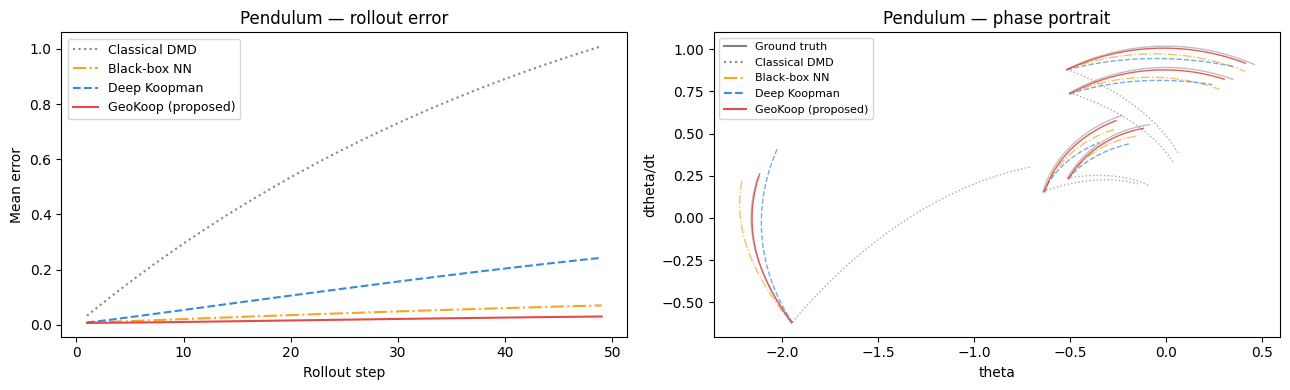

Saved pendulum_results.png


In [13]:
# Pendulum — figures (four models)
from matplotlib.lines import Line2D

fig, axes = plt.subplots(1, 2, figsize=(13, 4))
ts = np.arange(1, 50)

# Rollout error
ax = axes[0]
ax.plot(ts, err_p_dmd,  color=COLORS['DMD'],      ls=STYLES['DMD'],      lw=1.5, label='Classical DMD')
ax.plot(ts, err_p_bb,   color=COLORS['BlackBox'],  ls=STYLES['BlackBox'], lw=1.5, label='Black-box NN')
ax.plot(ts, err_p_base, color=COLORS['Baseline'],  ls=STYLES['Baseline'], lw=1.5, label='Deep Koopman')
ax.plot(ts, err_p_geo,  color=COLORS['GeoKoop'],   ls=STYLES['GeoKoop'],  lw=1.5, label='GeoKoop (proposed)')
ax.set_xlabel('Rollout step'); ax.set_ylabel('Mean error')
ax.set_title('Pendulum — rollout error'); ax.legend(fontsize=9)

# Phase portrait (5 test trajectories)
ax = axes[1]
mu_np  = mu.squeeze().cpu().numpy()
sig_np = sig.squeeze().cpu().numpy()

for i in range(5):
    x0 = X_te_n[i, 0:1, :].to(device)
    with torch.no_grad():
        # DMD (in obs space)
        z0d = X_te_n[i, 0, :].cpu().numpy() * sig_np + mu_np
        dmd_traj = [z0d]; zr = z0d.copy()
        for _ in range(49): zr = A_dmd_p @ zr; dmd_traj.append(zr)
        dmd_traj = np.stack(dmd_traj)

        # Black-box
        z = ae_p_bb.encode(x0)
        pbb = [ae_p_bb.decode(z).cpu().numpy()]
        for _ in range(49): z = bb_p(z); pbb.append(ae_p_bb.decode(z).cpu().numpy())
        pbb = np.vstack(pbb) * sig_np + mu_np

        # Deep Koopman
        z = ae_p_base.encode(x0)
        pb = [ae_p_base.decode(z).cpu().numpy()]
        for _ in range(49): z = koop_p_base(z); pb.append(ae_p_base.decode(z).cpu().numpy())
        pb = np.vstack(pb) * sig_np + mu_np

        # GeoKoop
        z = ae_p_geo.encode(x0)
        pg = [ae_p_geo.decode(z).cpu().numpy()]
        for _ in range(49): z = koop_p_geo(z); pg.append(ae_p_geo.decode(z).cpu().numpy())
        pg = np.vstack(pg) * sig_np + mu_np

    true = X_te_n[i].cpu().numpy() * sig_np + mu_np
    ax.plot(true[:,0],     true[:,1],     color='gray',               lw=1, alpha=0.5)
    ax.plot(dmd_traj[:,0], dmd_traj[:,1], color=COLORS['DMD'],        lw=1, ls=STYLES['DMD'],      alpha=0.7)
    ax.plot(pbb[:,0],      pbb[:,1],      color=COLORS['BlackBox'],   lw=1, ls=STYLES['BlackBox'], alpha=0.7)
    ax.plot(pb[:,0],       pb[:,1],       color=COLORS['Baseline'],   lw=1, ls=STYLES['Baseline'], alpha=0.7)
    ax.plot(pg[:,0],       pg[:,1],       color=COLORS['GeoKoop'],    lw=1, ls=STYLES['GeoKoop'],  alpha=0.9)

ax.legend(handles=[
    Line2D([0],[0], color='gray',              lw=1.5,                    label='Ground truth'),
    Line2D([0],[0], color=COLORS['DMD'],       lw=1.5, ls=STYLES['DMD'],      label='Classical DMD'),
    Line2D([0],[0], color=COLORS['BlackBox'],  lw=1.5, ls=STYLES['BlackBox'], label='Black-box NN'),
    Line2D([0],[0], color=COLORS['Baseline'],  lw=1.5, ls=STYLES['Baseline'], label='Deep Koopman'),
    Line2D([0],[0], color=COLORS['GeoKoop'],   lw=1.5,                    label='GeoKoop (proposed)'),
], fontsize=8)
ax.set_xlabel('theta'); ax.set_ylabel('dtheta/dt')
ax.set_title('Pendulum — phase portrait')

plt.tight_layout()
plt.savefig('pendulum_results.png', dpi=150, bbox_inches='tight')
plt.show()
shutil.copy('pendulum_results.png', f'{OUTPUT_DIR}/pendulum_results.png')
print('Saved pendulum_results.png')


---
## Pendulum Eigenvalue Analysis
Koopman backbone $K$ before (identity init) and after GeoKoop training.
Shows that training preserves a physically meaningful spectral structure
even on the nonlinear pendulum.


Pendulum eigenvalue spectrum:
                                     |λ|       angle    period
  Identity init:
    |λ|=1.0000  angle=0.0000  period=inf
    |λ|=1.0000  angle=0.0000  period=inf
    |λ|=1.0000  angle=0.0000  period=inf
    |λ|=1.0000  angle=0.0000  period=inf
  Deep Koopman K:
    |λ|=1.0000  angle=0.0000  period=inf
    |λ|=0.9997  angle=0.0140  period=447.20
    |λ|=0.9997  angle=0.0140  period=447.20
    |λ|=0.9858  angle=0.0000  period=inf
  GeoKoop K (λ_geo=0):
    |λ|=1.0000  angle=0.0194  period=323.36
    |λ|=1.0000  angle=0.0194  period=323.36
    |λ|=1.0000  angle=0.0088  period=711.44
    |λ|=1.0000  angle=0.0088  period=711.44


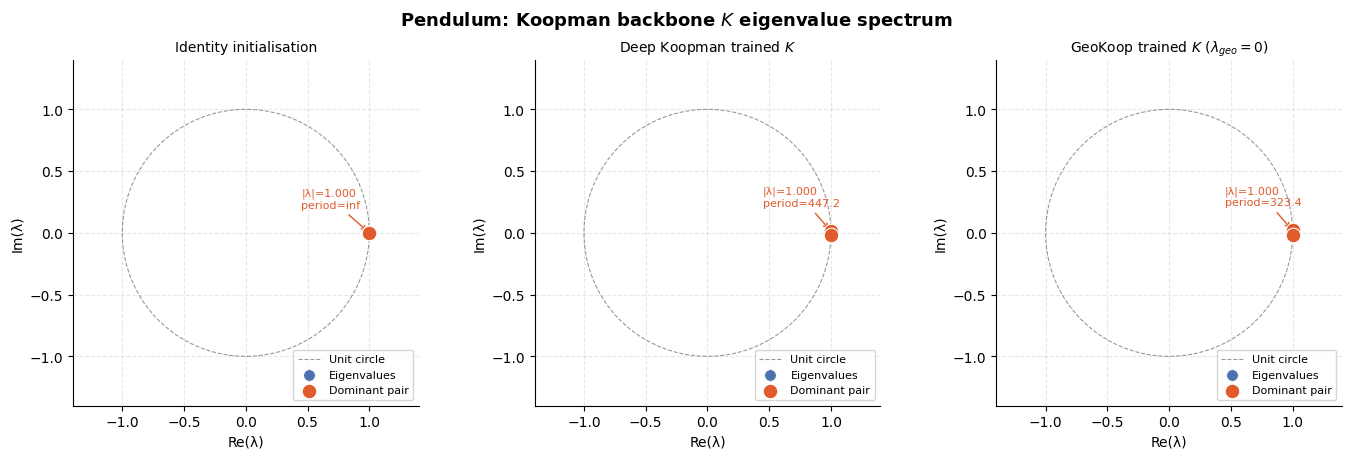

Saved pendulum_eigenvalues.png


In [14]:
# Pendulum eigenvalue analysis — K before and after training
theta_unit = np.linspace(0, 2*np.pi, 300)

K_p_geo   = koop_p_geo.K.detach().cpu().numpy()     # GeoKoop trained K
K_p_base  = koop_p_base.K.detach().cpu().numpy()    # Deep Koopman trained K
K_p_init  = np.eye(P_LATENT)                        # identity initialisation

eigs_init = np.linalg.eigvals(K_p_init)
eigs_base = np.linalg.eigvals(K_p_base)
eigs_geo  = np.linalg.eigvals(K_p_geo)

def sort_eigs(e): return e[np.argsort(-np.abs(e))]
eigs_init = sort_eigs(eigs_init)
eigs_base = sort_eigs(eigs_base)
eigs_geo  = sort_eigs(eigs_geo)

print("Pendulum eigenvalue spectrum:")
print(f"{'':30s}  {'|λ|':>8s}  {'angle':>10s}  {'period':>8s}")
for label, eigs in [("Identity init", eigs_init),
                     ("Deep Koopman K", eigs_base),
                     ("GeoKoop K (λ_geo=0)", eigs_geo)]:
    print(f"  {label}:")
    for ev in eigs[:4]:
        mag   = np.abs(ev)
        angle = np.abs(np.angle(ev))
        period = 2*np.pi/angle if angle > 1e-6 else np.inf
        print(f"    |λ|={mag:.4f}  angle={angle:.4f}  period={period:.2f}")

fig, axes = plt.subplots(1, 3, figsize=(14, 4.5))
fig.suptitle("Pendulum: Koopman backbone $K$ eigenvalue spectrum",
             fontsize=13, fontweight='bold')

for ax, eigs, title in zip(
        axes,
        [eigs_init, eigs_base, eigs_geo],
        ["Identity initialisation",
         "Deep Koopman trained $K$",
         "GeoKoop trained $K$ ($\\lambda_{geo}=0$)"]):
    ax.plot(np.cos(theta_unit), np.sin(theta_unit),
            'k--', lw=0.8, alpha=0.4, label='Unit circle')
    ax.scatter(eigs.real, eigs.imag,
               c='#4C72B0', s=70, zorder=4,
               edgecolors='white', linewidth=0.5, label='Eigenvalues')
    # Dominant pair
    dom_idx = np.argmax(np.abs(eigs.imag))
    dom = eigs[dom_idx]
    conj_idx = np.argmin(np.abs(eigs - dom.conj()))
    conj = eigs[conj_idx]
    ax.scatter([dom.real, conj.real], [dom.imag, conj.imag],
               c='#E05A2B', s=110, zorder=5,
               edgecolors='white', linewidth=0.8, label='Dominant pair')
    angle = np.abs(np.angle(dom))
    period = 2*np.pi/angle if angle > 1e-6 else np.inf
    ax.annotate(
        f"|λ|={np.abs(dom):.3f}\nperiod={period:.1f}",
        xy=(dom.real, dom.imag),
        xytext=(dom.real - 0.55, dom.imag + 0.2),
        fontsize=8, color='#E05A2B',
        arrowprops=dict(arrowstyle='->', color='#E05A2B', lw=1.0))
    ax.set_xlim(-1.4, 1.4); ax.set_ylim(-1.4, 1.4)
    ax.set_aspect('equal')
    ax.set_xlabel('Re(λ)', fontsize=10)
    ax.set_ylabel('Im(λ)', fontsize=10)
    ax.set_title(title, fontsize=10)
    ax.legend(fontsize=8, loc='lower right')
    ax.grid(True, linestyle='--', alpha=0.3)
    ax.spines[['top','right']].set_visible(False)

plt.tight_layout()
for fname in ['pendulum_eigenvalues.png',
              f'{OUTPUT_DIR}/pendulum_eigenvalues.png',
              f'{FIG_DIR}/pendulum_eigenvalues.png']:
    plt.savefig(fname, dpi=150, bbox_inches='tight')
plt.show()
print("Saved pendulum_eigenvalues.png")


---
## Mechanism Test: N(z_t) ≈ J_f(z_t) − K
Test whether the learned correction N(z_t) approximates the local flow
Jacobian minus the global backbone. Uses finite-difference Jacobian
estimation along test trajectories.


Sampled 200 latent states, shape=(200, 4)

Mechanism test: N(z_t) ≈ J_f(z_t) - K  (pendulum, d=4)
  ||N(z)||_F           mean=0.0505  std=0.0198
  ||J_f(z)-K||_F       mean=0.0604  std=0.0187
  ||N(z)-(J_f-K)||_F   mean=0.0301  std=0.0134
  Relative error       mean=0.5145  std=0.2170
  Element-wise Pearson r: mean=0.8200  std=0.1799  n=200

RESULT: STRONG — N(z) ≈ J_f(z) - K is supported.


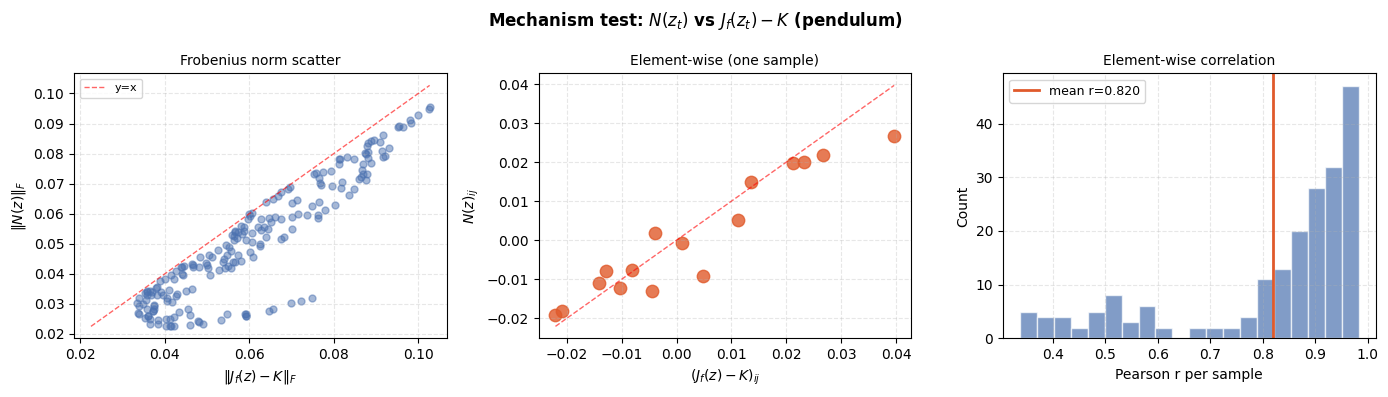

Saved pendulum_mechanism.png


In [15]:
# Mechanism test: N(z_t) ≈ J_f(z_t) - K  (pendulum)
# Estimate J_f(z_t) via finite differences, compare to K + N(z_t)

koop_p_geo.eval()
ae_p_geo.eval()
_dev = next(koop_p_geo.parameters()).device   # get model device (cpu or cuda)

def latent_dynamics_fn(koop, z_np):
    """Apply Koopman dynamics: numpy in, numpy out. Handles GPU correctly."""
    z_t = torch.tensor(z_np, dtype=torch.float32).unsqueeze(0).to(_dev)
    with torch.no_grad():
        return koop(z_t).squeeze(0).cpu().numpy()

def finite_diff_jacobian(fn, z, eps=1e-4):
    """Estimate d x d Jacobian of fn at z via central differences."""
    d = len(z)
    J = np.zeros((d, d))
    for j in range(d):
        zp = z.copy(); zp[j] += eps
        zm = z.copy(); zm[j] -= eps
        J[:, j] = (fn(zp) - fn(zm)) / (2 * eps)
    return J

# Sample latent states from pendulum test trajectories
N_SAMPLES = 200
latent_states = []

with torch.no_grad():
    for i in range(min(N_SAMPLES, X_te_n.shape[0])):
        x_in = X_te_n[i, 0, :]
        # handle both tensor and numpy input
        if isinstance(x_in, torch.Tensor):
            x_in = x_in.float()
        else:
            x_in = torch.tensor(x_in, dtype=torch.float32)
        z = ae_p_geo.encode(x_in.unsqueeze(0).to(_dev)).squeeze(0).cpu().numpy()
        latent_states.append(z)

latent_states = np.array(latent_states[:N_SAMPLES])
print(f"Sampled {len(latent_states)} latent states, shape={latent_states.shape}")

# K on CPU for numpy comparison
K_np = koop_p_geo.K.detach().cpu().numpy()

def geo_dynamics(z_np):
    return latent_dynamics_fn(koop_p_geo, z_np)

residuals    = []
N_norms      = []
Jf_K_norms   = []
correlations = []

for z in latent_states:
    # Finite-difference Jacobian
    Jf = finite_diff_jacobian(geo_dynamics, z)

    # N(z) from network — move to device, back to cpu
    z_t = torch.tensor(z, dtype=torch.float32).unsqueeze(0).to(_dev)
    with torch.no_grad():
        N_z = koop_p_geo.N_net(z_t).view(P_LATENT, P_LATENT).cpu().numpy()

    Jf_minus_K = Jf - K_np
    residual   = N_z - Jf_minus_K

    residuals.append(np.linalg.norm(residual, 'fro'))
    N_norms.append(np.linalg.norm(N_z, 'fro'))
    Jf_K_norms.append(np.linalg.norm(Jf_minus_K, 'fro'))

    n_flat = N_z.flatten()
    j_flat = Jf_minus_K.flatten()
    if np.std(n_flat) > 1e-8 and np.std(j_flat) > 1e-8:
        correlations.append(np.corrcoef(n_flat, j_flat)[0, 1])

residuals    = np.array(residuals)
N_norms      = np.array(N_norms)
Jf_K_norms   = np.array(Jf_K_norms)
correlations = np.array(correlations)

print()
print("=" * 60)
print("Mechanism test: N(z_t) ≈ J_f(z_t) - K  (pendulum, d=4)")
print("=" * 60)
print(f"  ||N(z)||_F           mean={N_norms.mean():.4f}  std={N_norms.std():.4f}")
print(f"  ||J_f(z)-K||_F       mean={Jf_K_norms.mean():.4f}  std={Jf_K_norms.std():.4f}")
print(f"  ||N(z)-(J_f-K)||_F   mean={residuals.mean():.4f}  std={residuals.std():.4f}")
rel_error = residuals / (Jf_K_norms + 1e-8)
print(f"  Relative error       mean={rel_error.mean():.4f}  std={rel_error.std():.4f}")
print(f"  Element-wise Pearson r: mean={correlations.mean():.4f}  "
      f"std={correlations.std():.4f}  "
      f"n={len(correlations)}")
print()
if correlations.mean() > 0.5:
    print("RESULT: STRONG — N(z) ≈ J_f(z) - K is supported.")
elif correlations.mean() > 0.2:
    print("RESULT: MODERATE — partial support for N(z) ≈ J_f(z) - K.")
else:
    print("RESULT: WEAK — N(z) ≈ J_f(z) - K is not strongly supported.")

# ── Figure ──────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(14, 4))
fig.suptitle("Mechanism test: $N(z_t)$ vs $J_f(z_t)-K$ (pendulum)",
             fontsize=12, fontweight='bold')

# Panel 1: Frobenius norm comparison
axes[0].scatter(Jf_K_norms, N_norms, alpha=0.5, s=25, color='#4C72B0')
lims = [min(Jf_K_norms.min(), N_norms.min()),
        max(Jf_K_norms.max(), N_norms.max())]
axes[0].plot(lims, lims, 'r--', lw=1, alpha=0.6, label='y=x')
axes[0].set_xlabel(r"$\|J_f(z)-K\|_F$", fontsize=10)
axes[0].set_ylabel(r"$\|N(z)\|_F$", fontsize=10)
axes[0].set_title("Frobenius norm scatter", fontsize=10)
axes[0].legend(fontsize=8); axes[0].grid(True, linestyle='--', alpha=0.3)

# Panel 2: element-wise scatter (one sample)
z_s = latent_states[0]
z_t = torch.tensor(z_s, dtype=torch.float32).unsqueeze(0).to(_dev)
with torch.no_grad():
    N_s = koop_p_geo.N_net(z_t).view(P_LATENT, P_LATENT).cpu().numpy()
Jf_s   = finite_diff_jacobian(geo_dynamics, z_s)
JfK_s  = Jf_s - K_np
axes[1].scatter(JfK_s.flatten(), N_s.flatten(),
                alpha=0.8, s=80, color='#E05A2B')
lims2 = [min(JfK_s.min(), N_s.min()), max(JfK_s.max(), N_s.max())]
axes[1].plot(lims2, lims2, 'r--', lw=1, alpha=0.6)
axes[1].set_xlabel(r"$(J_f(z)-K)_{ij}$", fontsize=10)
axes[1].set_ylabel(r"$N(z)_{ij}$", fontsize=10)
axes[1].set_title("Element-wise (one sample)", fontsize=10)
axes[1].grid(True, linestyle='--', alpha=0.3)

# Panel 3: distribution of correlations
axes[2].hist(correlations, bins=20, color='#4C72B0',
             alpha=0.7, edgecolor='white')
axes[2].axvline(correlations.mean(), color='#E05A2B', lw=2,
                label=f'mean r={correlations.mean():.3f}')
axes[2].set_xlabel("Pearson r per sample", fontsize=10)
axes[2].set_ylabel("Count", fontsize=10)
axes[2].set_title("Element-wise correlation", fontsize=10)
axes[2].legend(fontsize=9)
axes[2].grid(True, linestyle='--', alpha=0.3)

plt.tight_layout()
for fname in ['pendulum_mechanism.png',
              f'{OUTPUT_DIR}/pendulum_mechanism.png',
              f'{FIG_DIR}/pendulum_mechanism.png']:
    plt.savefig(fname, dpi=150, bbox_inches='tight')
plt.show()
# Store as mech_pend for multi-system summary
mech_pend = dict(
    label=f"Pendulum (d={P_LATENT})",
    latent_dim=P_LATENT,
    n=len(latent_states),
    N_norms=N_norms,
    Jf_K_norms=Jf_K_norms,
    residuals=residuals,
    correlations=correlations,
    latent_states=latent_states,
)
print("Saved pendulum_mechanism.png")


In [16]:
# ── Shared mechanism-test helpers (run once) ─────────────────────
def get_device(model):
    return next(model.parameters()).device

def make_latent_dynamics_fn(koop):
    _dev = get_device(koop)
    def fn(z_np):
        z_t = torch.tensor(z_np, dtype=torch.float32).unsqueeze(0).to(_dev)
        with torch.no_grad():
            return koop(z_t).squeeze(0).cpu().numpy()
    return fn

def finite_diff_jacobian(fn, z, eps=1e-4):
    d = len(z)
    J = np.zeros((d, d))
    for j in range(d):
        zp = z.copy(); zp[j] += eps
        zm = z.copy(); zm[j] -= eps
        J[:, j] = (fn(zp) - fn(zm)) / (2*eps)
    return J

def run_mechanism_test(koop, ae, K_np, latent_dim,
                       x_samples, label, n_samples=200):
    """
    Test N(z) ≈ J_f(z) - K on n_samples latent states.
    x_samples: numpy array (N, input_dim) of raw input states.
    Returns dict with stats and arrays for plotting.
    """
    _dev = get_device(koop)
    koop.eval(); ae.eval()
    dyn_fn = make_latent_dynamics_fn(koop)

    # Encode samples to latent
    latent_states = []
    with torch.no_grad():
        for i in range(min(n_samples, len(x_samples))):
            x = torch.tensor(x_samples[i], dtype=torch.float32
                             ).unsqueeze(0).to(_dev)
            z = ae.encode(x).squeeze(0).cpu().numpy()
            latent_states.append(z)
    latent_states = np.array(latent_states)

    residuals, N_norms, Jf_K_norms, correlations = [], [], [], []

    for z in latent_states:
        Jf       = finite_diff_jacobian(dyn_fn, z)
        z_t      = torch.tensor(z, dtype=torch.float32).unsqueeze(0).to(_dev)
        with torch.no_grad():
            N_z  = koop.N_net(z_t).view(latent_dim, latent_dim).cpu().numpy()
        Jf_K     = Jf - K_np
        residuals.append(np.linalg.norm(N_z - Jf_K, "fro"))
        N_norms.append(np.linalg.norm(N_z, "fro"))
        Jf_K_norms.append(np.linalg.norm(Jf_K, "fro"))
        nf, jf = N_z.flatten(), Jf_K.flatten()
        if np.std(nf) > 1e-8 and np.std(jf) > 1e-8:
            correlations.append(np.corrcoef(nf, jf)[0,1])

    res = dict(
        label        = label,
        latent_dim   = latent_dim,
        n            = len(latent_states),
        N_norms      = np.array(N_norms),
        Jf_K_norms   = np.array(Jf_K_norms),
        residuals    = np.array(residuals),
        correlations = np.array(correlations),
        latent_states= latent_states,
    )
    rel = res["residuals"] / (res["Jf_K_norms"] + 1e-8)
    r   = res["correlations"]
    print(f"\n{'='*55}")
    print(f"Mechanism test: N(z) ≈ J_f(z)-K  [{label}]")
    print(f"{'='*55}")
    print(f"  Samples : {res['n']}  (latent d={latent_dim})")
    print(f"  ||N(z)||_F        mean={res['N_norms'].mean():.4f}  "
          f"std={res['N_norms'].std():.4f}")
    print(f"  ||J_f-K||_F       mean={res['Jf_K_norms'].mean():.4f}  "
          f"std={res['Jf_K_norms'].std():.4f}")
    print(f"  ||N-(J_f-K)||_F   mean={res['residuals'].mean():.4f}  "
          f"std={res['residuals'].std():.4f}")
    print(f"  Relative error    mean={rel.mean():.4f}  std={rel.std():.4f}")
    print(f"  Pearson r         mean={r.mean():.4f}  std={r.std():.4f}  n={len(r)}")
    verdict = ("STRONG" if r.mean() > 0.5 else
               "MODERATE" if r.mean() > 0.2 else "WEAK")
    print(f"  RESULT: {verdict}")
    return res

print("Mechanism-test helpers ready.")


Mechanism-test helpers ready.


---
## Experiment 2 — FluidFlowBox
Off-attractor trajectories from Noack mean-field model → **1.16× improvement expected**

In [17]:
# ── Cell 7: FluidFlowBox — load data ──────────────────────────────
F_SEQ = 51

X_f_tr = load_lusch(DATA_DIR, 'FluidFlowBox', 'train1', F_SEQ)
X_f_va = load_lusch(DATA_DIR, 'FluidFlowBox', 'val',    F_SEQ)
X_f_te = load_lusch(DATA_DIR, 'FluidFlowBox', 'test',   F_SEQ)
print(f'FluidFlowBox — train: {X_f_tr.shape}  val: {X_f_va.shape}  test: {X_f_te.shape}')

f_mu  = X_f_tr.mean(dim=(0,1), keepdim=True)
f_sig = X_f_tr.std(dim=(0,1),  keepdim=True) + 1e-8
X_f_tr_n = ((X_f_tr - f_mu) / f_sig).to(device)
X_f_te_n = ((X_f_te - f_mu) / f_sig).to(device)

f_xt   = X_f_tr_n[:, :-1, :].reshape(-1, 3)
f_xtp1 = X_f_tr_n[:, 1:,  :].reshape(-1, 3)
print(f'Training pairs: {f_xt.shape}')
X_f_va_n = ((X_f_va - f_mu) / f_sig).to(device)
print('FluidFlowBox data loaded.')


FluidFlowBox — train: torch.Size([9901, 51, 3])  val: torch.Size([9901, 51, 3])  test: torch.Size([9901, 51, 3])
Training pairs: torch.Size([495050, 3])
FluidFlowBox data loaded.


In [18]:
# FluidFlowBox — train all four models
F_LATENT = 6

# ── Model 1: Classical Koopman / DMD ──────────────────────────
print('=== Model 1: Classical Koopman / DMD ===')
print('  Analytic operator on 3D Noack state. No encoder, no training.')
f_data_dmd = X_f_tr_n[:, :-1, :].reshape(-1, 3).cpu().numpy().T  # (3, N)
A_dmd_f    = dmd_matrix(f_data_dmd, rank=3)
eigs_dmd_f = np.linalg.eigvals(A_dmd_f)
print(f'  Operator size:   {A_dmd_f.shape}')
print(f'  Spectral radius: {max(abs(eigs_dmd_f)):.6f}')
print(f'  Eigenvalues:     {eigs_dmd_f}')
print(f'  Global linear; cannot track off-attractor transient geometry.')

print('\n=== Model 2: Black-box NN ===')
ae_f_bb  = AE(3, F_LATENT, hidden=128).to(device)
bb_f     = BlackBoxNN(F_LATENT, hidden=64).to(device)
train_blackbox(ae_f_bb, bb_f, f_xt, f_xtp1, 'Fluid-BB',
               epochs_p1=1000, epochs_p2=2000, rollout_steps=20)

print('\n=== Model 3: Deep Koopman (Baseline) ===')
ae_f_base   = AE(3, F_LATENT, hidden=128).to(device)
koop_f_base = KoopmanCore(F_LATENT, use_geo=False).to(device)
train_model(ae_f_base, koop_f_base, f_xt, f_xtp1,
            use_geo=False, label='Fluid-Base',
            epochs_p1=1000, epochs_p2=2000, rollout_steps=20)

print('\n=== Model 4: GeoKoop ===')
ae_f_geo   = AE(3, F_LATENT, hidden=128).to(device)
koop_f_geo = KoopmanCore(F_LATENT, use_geo=True).to(device)
train_model(ae_f_geo, koop_f_geo, f_xt, f_xtp1,
            use_geo=True, label='Fluid-Geo',
            epochs_p1=1000, epochs_p2=2000, rollout_steps=20, lam_geo=0.0)  # unregularised: recommended

# Rollout errors
def fluid_dmd_rollout_err(X_data, steps=49):
    f_mu_np  = f_mu.squeeze().cpu().numpy()
    f_sig_np = f_sig.squeeze().cpu().numpy()
    errs = []
    for i in range(X_data.shape[0]):
        z0 = X_data[i, 0, :].cpu().numpy() * f_sig_np + f_mu_np
        traj = [z0]; zr = z0.copy()
        for _ in range(steps): zr = A_dmd_f @ zr; traj.append(zr)
        traj = np.stack(traj)  # (steps+1, 3)
        true = X_data[i].cpu().numpy() * f_sig_np + f_mu_np  # (51, 3)
        errs.append(np.linalg.norm(traj[1:] - true[1:steps+1], axis=1))
    return np.stack(errs).mean(axis=0)

err_f_dmd  = fluid_dmd_rollout_err(X_f_te_n)
err_f_bb   = rollout_error(ae_f_bb,   bb_f,        X_f_te_n, steps=49)
err_f_base = rollout_error(ae_f_base, koop_f_base, X_f_te_n, steps=49)
err_f_geo  = rollout_error(ae_f_geo,  koop_f_geo,  X_f_te_n, steps=49)

print('FluidFlowBox rollout@49:')
print(f'  DMD:          {err_f_dmd[-1]:.4f}')
print(f'  Black-box NN: {err_f_bb[-1]:.4f}  vs GeoKoop: {err_f_bb[-1]/err_f_geo[-1]:.2f}x')
print(f'  Deep Koopman: {err_f_base[-1]:.4f}  vs GeoKoop: {err_f_base[-1]/err_f_geo[-1]:.2f}x')
print(f'  GeoKoop:      {err_f_geo[-1]:.4f}')


=== Model 1: Classical Koopman / DMD ===
  Analytic operator on 3D Noack state. No encoder, no training.
  Operator size:   (3, 3)
  Spectral radius: 0.989941
  Eigenvalues:     [0.98988974+0.01005076j 0.98988974-0.01005076j 0.97973067+0.j        ]
  Global linear; cannot track off-attractor transient geometry.

=== Model 2: Black-box NN ===
[Fluid-BB]    0 | rec=1.01471 dyn=0.04627 roll=0.00000
[Fluid-BB]  200 | rec=0.00193 dyn=0.00690 roll=0.00000
[Fluid-BB]  400 | rec=0.00039 dyn=0.00436 roll=0.00000
[Fluid-BB]  600 | rec=0.00017 dyn=0.00337 roll=0.00000
[Fluid-BB]  800 | rec=0.00009 dyn=0.00284 roll=0.00000
[Fluid-BB] 1000 | rec=0.00005 dyn=0.00247 roll=0.02188
[Fluid-BB] 1200 | rec=0.00005 dyn=0.00139 roll=0.01205
[Fluid-BB] 1400 | rec=0.00008 dyn=0.00101 roll=0.00875
[Fluid-BB] 1600 | rec=0.00028 dyn=0.00081 roll=0.00700
[Fluid-BB] 1800 | rec=0.00003 dyn=0.00069 roll=0.00590
[Fluid-BB] 2000 | rec=0.00003 dyn=0.00060 roll=0.00511
[Fluid-BB] 2200 | rec=0.00002 dyn=0.00055 roll=0.00

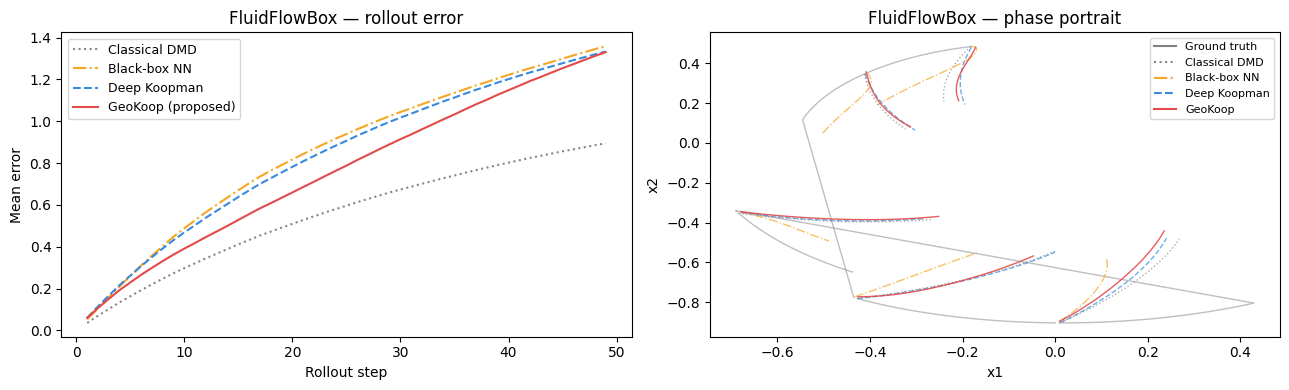

Saved fluidflowbox_results.png


In [19]:
# FluidFlowBox — figures (four models)
fig, axes = plt.subplots(1, 2, figsize=(13, 4))
ts = np.arange(1, 50)
f_mu_np  = f_mu.squeeze().cpu().numpy()
f_sig_np = f_sig.squeeze().cpu().numpy()

ax = axes[0]
ax.plot(ts, err_f_dmd,  color=COLORS['DMD'],      ls=STYLES['DMD'],      lw=1.5, label='Classical DMD')
ax.plot(ts, err_f_bb,   color=COLORS['BlackBox'],  ls=STYLES['BlackBox'], lw=1.5, label='Black-box NN')
ax.plot(ts, err_f_base, color=COLORS['Baseline'],  ls=STYLES['Baseline'], lw=1.5, label='Deep Koopman')
ax.plot(ts, err_f_geo,  color=COLORS['GeoKoop'],   ls=STYLES['GeoKoop'],  lw=1.5, label='GeoKoop (proposed)')
ax.set_xlabel('Rollout step'); ax.set_ylabel('Mean error')
ax.set_title('FluidFlowBox — rollout error'); ax.legend(fontsize=9)

ax = axes[1]
for i in range(5):
    x0 = X_f_te_n[i, 0:1, :].to(device)
    with torch.no_grad():
        z0d = X_f_te_n[i, 0, :].cpu().numpy() * f_sig_np + f_mu_np
        dmd_traj = [z0d]; zr = z0d.copy()
        for _ in range(49): zr = A_dmd_f @ zr; dmd_traj.append(zr)
        dmd_traj = np.stack(dmd_traj)

        z = ae_f_bb.encode(x0)
        pbb = [ae_f_bb.decode(z).cpu().numpy()]
        for _ in range(49): z = bb_f(z); pbb.append(ae_f_bb.decode(z).cpu().numpy())
        pbb = np.vstack(pbb) * f_sig_np + f_mu_np

        z = ae_f_base.encode(x0)
        pb = [ae_f_base.decode(z).cpu().numpy()]
        for _ in range(49): z = koop_f_base(z); pb.append(ae_f_base.decode(z).cpu().numpy())
        pb = np.vstack(pb) * f_sig_np + f_mu_np

        z = ae_f_geo.encode(x0)
        pg = [ae_f_geo.decode(z).cpu().numpy()]
        for _ in range(49): z = koop_f_geo(z); pg.append(ae_f_geo.decode(z).cpu().numpy())
        pg = np.vstack(pg) * f_sig_np + f_mu_np

    true = X_f_te_n[i].cpu().numpy() * f_sig_np + f_mu_np
    ax.plot(true[:,0],     true[:,1],     color='gray',              lw=1, alpha=0.5)
    ax.plot(dmd_traj[:,0], dmd_traj[:,1], color=COLORS['DMD'],       lw=1, ls=STYLES['DMD'],      alpha=0.7)
    ax.plot(pbb[:,0],      pbb[:,1],      color=COLORS['BlackBox'],  lw=1, ls=STYLES['BlackBox'], alpha=0.7)
    ax.plot(pb[:,0],       pb[:,1],       color=COLORS['Baseline'],  lw=1, ls=STYLES['Baseline'], alpha=0.7)
    ax.plot(pg[:,0],       pg[:,1],       color=COLORS['GeoKoop'],   lw=1, ls=STYLES['GeoKoop'],  alpha=0.9)

ax.legend(handles=[
    Line2D([0],[0], color='gray',             lw=1.5,                    label='Ground truth'),
    Line2D([0],[0], color=COLORS['DMD'],      lw=1.5, ls=STYLES['DMD'],      label='Classical DMD'),
    Line2D([0],[0], color=COLORS['BlackBox'], lw=1.5, ls=STYLES['BlackBox'], label='Black-box NN'),
    Line2D([0],[0], color=COLORS['Baseline'], lw=1.5, ls=STYLES['Baseline'], label='Deep Koopman'),
    Line2D([0],[0], color=COLORS['GeoKoop'],  lw=1.5,                    label='GeoKoop'),
], fontsize=8)
ax.set_xlabel('x1'); ax.set_ylabel('x2')
ax.set_title('FluidFlowBox — phase portrait')
plt.tight_layout()
plt.savefig('fluidflowbox_results.png', dpi=150, bbox_inches='tight')
plt.show()
shutil.copy('fluidflowbox_results.png', f'{OUTPUT_DIR}/fluidflowbox_results.png')
print('Saved fluidflowbox_results.png')


---
## Experiment 3 — Cylinder Vortex Shedding
89,351-dimensional, r=32 SVD modes → **11× improvement expected**

In [20]:
# ── Cell 10: Cylinder — load & compress ───────────────────────────
assert os.path.exists(CYLINDER), f'Not found: {CYLINDER}'

data     = scipy.io.loadmat(CYLINDER)
vort_all = data['VORTALL'].astype(np.float64)
vort_all = np.clip(vort_all, -10.0, 10.0)
vort_all = (vort_all - vort_all.mean()) / vort_all.std()
space_dim, T_total = vort_all.shape
nx, ny = 449, 199
print(f'Cylinder data: {space_dim} x {T_total}')

r       = 32   # key: 32 not 100
n_train     = 140  # total snapshots used for training AE
n_koopman   = 100  # Koopman training window boundary (t=0..99)
                   # snapshots 100-149 are held-out evaluation

U_svd, _, _ = np.linalg.svd(vort_all, full_matrices=False)
X_reduced   = U_svd[:, :r].T @ vort_all
X_train     = X_reduced[:, :n_train]
C_mean      = X_train.mean(axis=1, keepdims=True)
C_std       = X_train.std(axis=1,  keepdims=True) + 1e-8
X_train_n   = (X_train - C_mean) / C_std

cx_t   = torch.tensor(X_train_n.T[:-1], dtype=torch.float32).to(device)
cx_tp1 = torch.tensor(X_train_n.T[1:],  dtype=torch.float32).to(device)

A_dmd_c = dmd_matrix(X_train_n, rank=20)
print(f'DMD spectral radius: {max(abs(np.linalg.eigvals(A_dmd_c))):.4f}')

Cylinder data: 89351 x 151
DMD spectral radius: 0.9826


In [21]:
# Cylinder — train all four models
C_LATENT = 16

def cyl_ae(latent):       return AE(r, latent, hidden=128).to(device)
def cyl_koop(latent, geo):
    K_init = np.array(A_dmd_c_orig if "A_dmd_c_orig" in dir() else A_dmd_c, dtype=np.float64)
    return KoopmanCore(latent, K_init=K_init, eps=1.0, use_geo=geo).to(device)

# ── Model 1: Classical Koopman / DMD ──────────────────────────
print('=== Model 1: Classical Koopman / DMD ===')
print('  DMD on r=32 SVD modes. Analytic — no encoder, no training.')
eigs_dmd_c = np.linalg.eigvals(A_dmd_c)
print(f'  Operator size:   {A_dmd_c.shape}')
print(f'  Spectral radius: {max(abs(eigs_dmd_c)):.6f}')
print(f'  Dominant freqs:  {sorted(abs(eigs_dmd_c), reverse=True)[:4]}')
print(f'  K_init for Models 3&4 also set from A_dmd_c (warm start).')

print('\n=== Model 2: Black-box NN ===')
ae_c_bb  = cyl_ae(C_LATENT)
bb_c     = BlackBoxNN(C_LATENT, hidden=64).to(device)
train_blackbox(ae_c_bb, bb_c, cx_t, cx_tp1, 'Cyl-BB',
               epochs_p1=500, epochs_p2=3000, rollout_steps=20)

print('\n=== Model 3: Deep Koopman (Baseline) ===')
ae_c_base   = cyl_ae(C_LATENT)
koop_c_base = cyl_koop(C_LATENT, geo=False)
train_model(ae_c_base, koop_c_base, cx_t, cx_tp1,
            use_geo=False, label='Cyl-Base',
            epochs_p1=500, epochs_p2=3000, rollout_steps=20)

print('\n=== Model 4: GeoKoop ===')
ae_c_geo   = cyl_ae(C_LATENT)
koop_c_geo = cyl_koop(C_LATENT, geo=True)
train_model(ae_c_geo, koop_c_geo, cx_t, cx_tp1,
            use_geo=True, label='Cyl-Geo',
            epochs_p1=500, epochs_p2=3000, rollout_steps=20, lam_geo=0.0)  # unregularised: recommended


=== Model 1: Classical Koopman / DMD ===
  DMD on r=32 SVD modes. Analytic — no encoder, no training.
  Operator size:   (32, 32)
  Spectral radius: 0.982590
  Dominant freqs:  [np.float64(0.9825900991475355), np.float64(0.9698264384169292), np.float64(0.9698264384169292), np.float64(0.9404602249138276)]
  K_init for Models 3&4 also set from A_dmd_c (warm start).

=== Model 2: Black-box NN ===
[Cyl-BB]    0 | rec=1.00727 dyn=0.03417 roll=0.00000
[Cyl-BB]  200 | rec=0.03282 dyn=0.04826 roll=0.00000
[Cyl-BB]  400 | rec=0.00068 dyn=0.00098 roll=0.00000
[Cyl-BB]  600 | rec=0.00032 dyn=0.00022 roll=0.00054
[Cyl-BB]  800 | rec=0.00017 dyn=0.00009 roll=0.00021
[Cyl-BB] 1000 | rec=0.00011 dyn=0.00005 roll=0.00012
[Cyl-BB] 1200 | rec=0.00009 dyn=0.00004 roll=0.00010
[Cyl-BB] 1400 | rec=0.00008 dyn=0.00004 roll=0.00008
[Cyl-BB] 1600 | rec=0.00007 dyn=0.00003 roll=0.00007
[Cyl-BB] 1800 | rec=0.00006 dyn=0.00002 roll=0.00005
[Cyl-BB] 2000 | rec=0.00005 dyn=0.00002 roll=0.00005
[Cyl-BB] 2200 | rec=

In [22]:
# Cylinder — rollout predictions and errors for all four models
def cyl_rollout(ae, dyn):
    ae.eval(); dyn.eval()
    with torch.no_grad():
        x0    = torch.tensor(X_train_n[:, 0],
                              dtype=torch.float32).unsqueeze(0).to(device)
        z     = ae.encode(x0)
        preds = [ae.decode(z).cpu().numpy()]
        for _ in range(T_total - 1):
            z = dyn(z); preds.append(ae.decode(z).cpu().numpy())
    X_n = np.vstack(preds).T
    return U_svd[:, :r] @ (X_n * C_std + C_mean)

# DMD rollout (no AE)
X_dmd = np.zeros((r, T_total))
X_dmd[:, 0] = X_train_n[:, 0]
for k in range(1, T_total): X_dmd[:, k] = A_dmd_c @ X_dmd[:, k-1]
X_dmd_full = U_svd[:, :r] @ (X_dmd * C_std + C_mean)

X_c_bb   = cyl_rollout(ae_c_bb,   bb_c)
X_c_base = cyl_rollout(ae_c_base, koop_c_base)
X_c_geo  = cyl_rollout(ae_c_geo,  koop_c_geo)

err_c_dmd  = np.linalg.norm(vort_all - X_dmd_full, axis=0)
err_c_bb   = np.linalg.norm(vort_all - X_c_bb,     axis=0)
err_c_base = np.linalg.norm(vort_all - X_c_base,   axis=0)
err_c_geo  = np.linalg.norm(vort_all - X_c_geo,    axis=0)

print('Cylinder mean error t=100-150:')
print(f'  DMD:          {err_c_dmd[100:].mean():.4f}')
print(f'  Black-box NN: {err_c_bb[100:].mean():.4f}  '
      f'vs GeoKoop: {err_c_bb[100:].mean()/err_c_geo[100:].mean():.2f}x')
print(f'  Deep Koopman: {err_c_base[100:].mean():.4f}  '
      f'vs GeoKoop: {err_c_base[100:].mean()/err_c_geo[100:].mean():.2f}x')
print(f'  GeoKoop:      {err_c_geo[100:].mean():.4f}')


Cylinder mean error t=100-150:
  DMD:          155.8199
  Black-box NN: 1.2736  vs GeoKoop: 1.67x
  Deep Koopman: 167.3842  vs GeoKoop: 219.37x
  GeoKoop:      0.7630


err_c_dmd: shape=(151,), mean(t=100-150)=155.8199
err_c_bb: shape=(151,), mean(t=100-150)=1.2736
err_c_base: shape=(151,), mean(t=100-150)=167.3842
err_c_geo: shape=(151,), mean(t=100-150)=0.7630


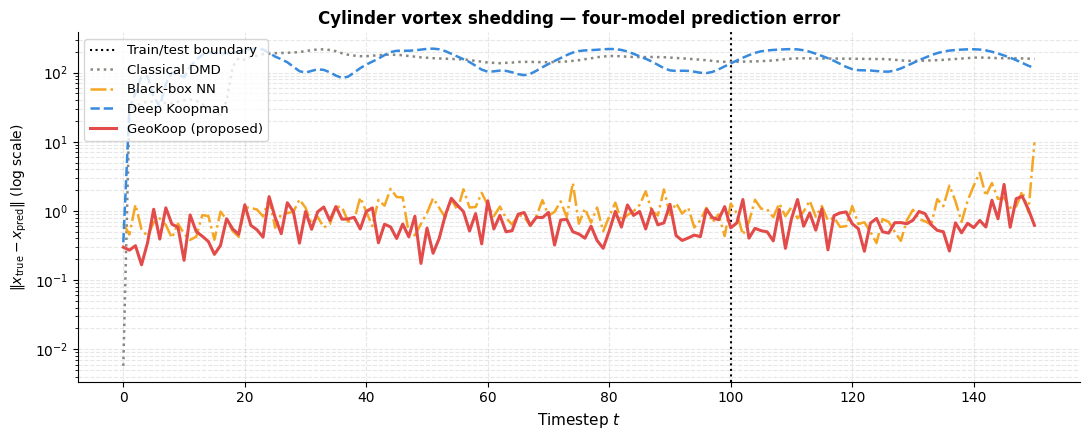

Saved cylinder_error.png


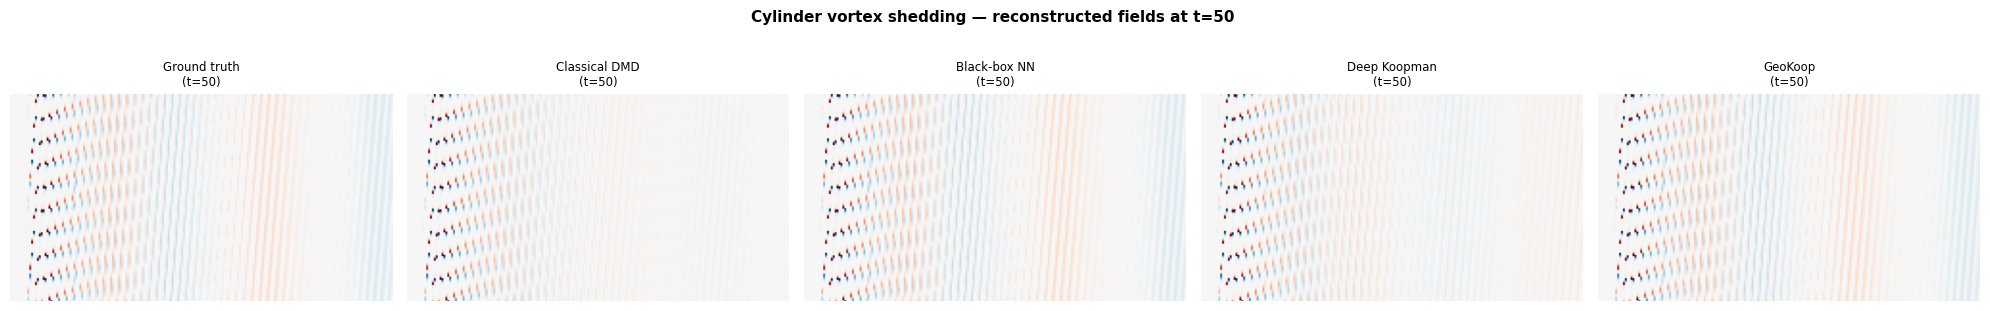

Saved cylinder_t50.png


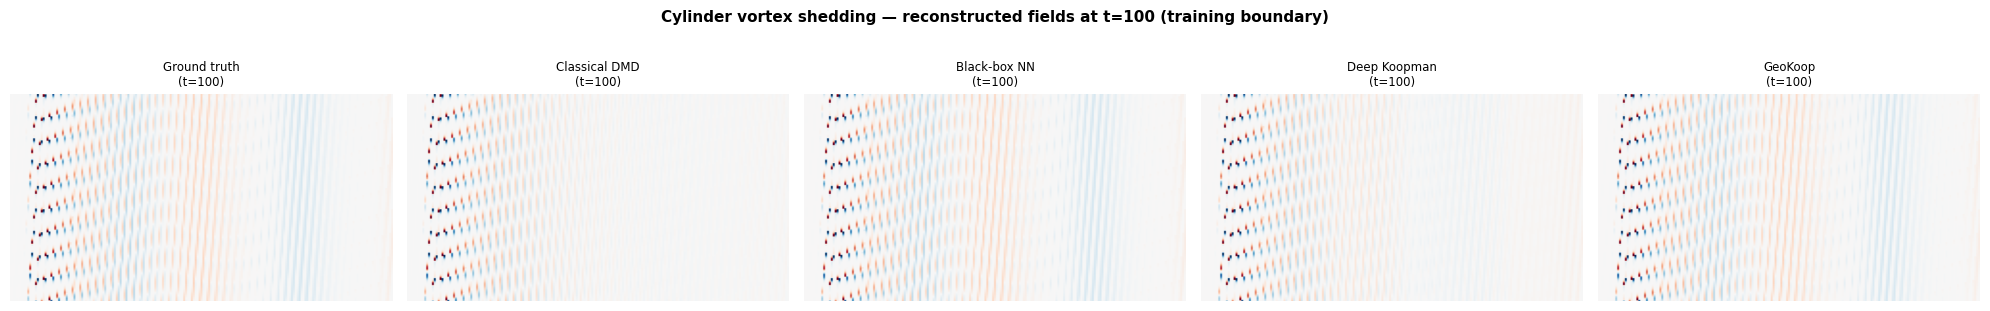

Saved cylinder_t100.png


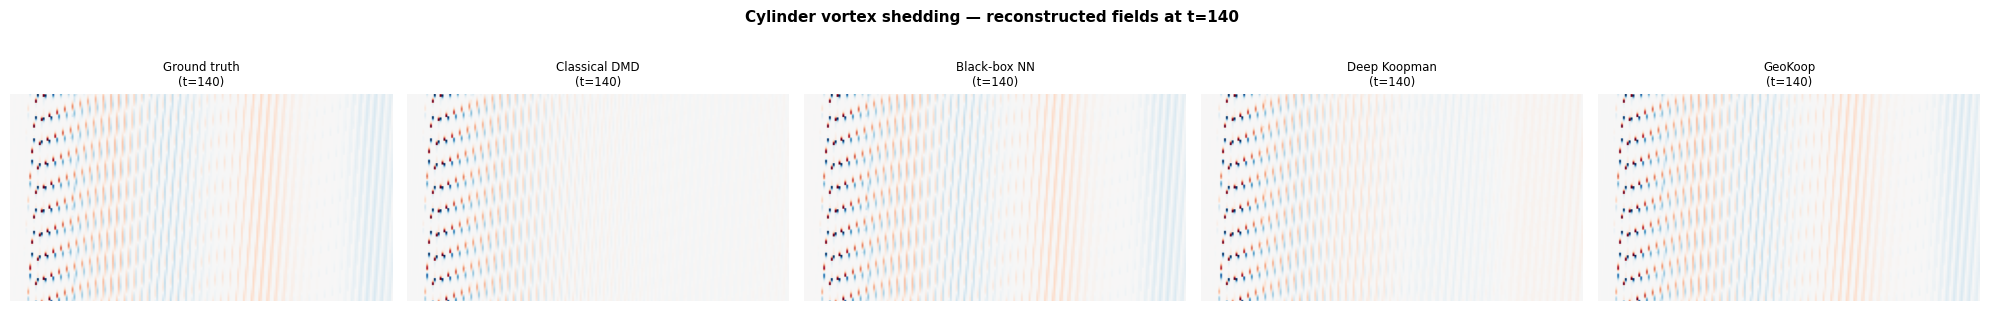

Saved cylinder_t140.png

Cylinder mean error t=100-150:
  DMD:          155.8199
  Black-box NN: 1.2736  vs GeoKoop: 1.67x
  Deep Koopman: 167.3842  vs GeoKoop: 219.37x
  GeoKoop:      0.7630


In [23]:
# Cylinder — figures (four models)
import os, shutil
os.makedirs(OUTPUT_DIR, exist_ok=True)
os.makedirs(FIG_DIR,    exist_ok=True)

# Training boundary for Koopman: first 100 snapshots
N_KOOPMAN_TRAIN = 100

# ── Guard: confirm all variables exist ─────────────────────────
required = {
    'err_c_dmd':  err_c_dmd,
    'err_c_bb':   err_c_bb,
    'err_c_base': err_c_base,
    'err_c_geo':  err_c_geo,
}
for name, arr in required.items():
    print(f'{name}: shape={arr.shape}, '
          f'mean(t=100-150)={arr[100:].mean():.4f}')

ts = np.arange(T_total)

# ── Figure 1: Four-model prediction error (log scale) ──────────
fig, ax = plt.subplots(figsize=(11, 4.5))
ax.axvline(N_KOOPMAN_TRAIN, color='k', ls=':', lw=1.5,
           label='Train/test boundary')
ax.semilogy(ts, err_c_dmd  + 1e-8,
            color=COLORS['DMD'],      ls=STYLES['DMD'],      lw=1.8,
            label='Classical DMD')
ax.semilogy(ts, err_c_bb   + 1e-8,
            color=COLORS['BlackBox'], ls=STYLES['BlackBox'], lw=1.8,
            label='Black-box NN')
ax.semilogy(ts, err_c_base + 1e-8,
            color=COLORS['Baseline'], ls=STYLES['Baseline'], lw=1.8,
            label='Deep Koopman')
ax.semilogy(ts, err_c_geo  + 1e-8,
            color=COLORS['GeoKoop'],  ls=STYLES['GeoKoop'],  lw=2.2,
            label='GeoKoop (proposed)')
ax.set_xlabel('Timestep $t$', fontsize=11)
ax.set_ylabel(r'$\|x_{\rm true} - x_{\rm pred}\|$ (log scale)',
              fontsize=10)
ax.set_title('Cylinder vortex shedding — four-model prediction error',
             fontsize=12, fontweight='bold')
ax.legend(fontsize=9.5, loc='upper left')
ax.grid(True, which='both', linestyle='--', alpha=0.3)
ax.spines[['top', 'right']].set_visible(False)
plt.tight_layout()
for fname in ['cylinder_error.png',
              f'{OUTPUT_DIR}/cylinder_error.png',
              f'{FIG_DIR}/cylinder_error.png']:
    plt.savefig(fname, dpi=150, bbox_inches='tight')
plt.show()
print('Saved cylinder_error.png')

# ── Figure 2: Vortex field snapshots — 5 columns ────────────────
for t in [50, 100, 140]:
    fig, axes = plt.subplots(1, 5, figsize=(20, 3))
    vmin = float(vort_all[:, t].min())
    vmax = float(vort_all[:, t].max())
    kw   = dict(cmap='RdBu_r', vmin=vmin, vmax=vmax, aspect='auto')

    panels = [
        ('Ground truth',  vort_all[:, t]),
        ('Classical DMD', X_dmd_full[:, t]),
        ('Black-box NN',  X_c_bb[:, t]),
        ('Deep Koopman',  X_c_base[:, t]),
        ('GeoKoop',       X_c_geo[:, t]),
    ]
    for ax, (title, arr) in zip(axes, panels):
        ax.imshow(arr.reshape(nx, ny, order='F'), **kw)
        ax.set_title(f'{title}\n(t={t})', fontsize=8.5)
        ax.axis('off')

    boundary_label = '(training boundary)' if t == N_KOOPMAN_TRAIN else ''
    plt.suptitle(
        f'Cylinder vortex shedding — reconstructed fields at '
        f't={t} {boundary_label}',
        fontsize=11, fontweight='bold', y=1.02)
    plt.tight_layout()
    for fname in [f'cylinder_t{t}.png',
                  f'{OUTPUT_DIR}/cylinder_t{t}.png',
                  f'{FIG_DIR}/cylinder_t{t}.png']:
        plt.savefig(fname, dpi=150, bbox_inches='tight')
    plt.show()
    print(f'Saved cylinder_t{t}.png')

# ── Summary stats ────────────────────────────────────────────────
print()
print('Cylinder mean error t=100-150:')
geo_mean = err_c_geo[100:].mean()
print(f'  DMD:          {err_c_dmd[100:].mean():.4f}')
print(f'  Black-box NN: {err_c_bb[100:].mean():.4f}  '
      f'vs GeoKoop: {err_c_bb[100:].mean()/geo_mean:.2f}x')
print(f'  Deep Koopman: {err_c_base[100:].mean():.4f}  '
      f'vs GeoKoop: {err_c_base[100:].mean()/geo_mean:.2f}x')
print(f'  GeoKoop:      {geo_mean:.4f}')


---
## Mechanism Test — Cylinder (d=16)
Test N(z) ≈ J_f(z) - K on the cylinder vortex shedding system.
Finite-difference Jacobian in the 16-dimensional latent space.



Mechanism test: N(z) ≈ J_f(z)-K  [Cylinder (d=16)]
  Samples : 100  (latent d=16)
  ||N(z)||_F        mean=3.3106  std=0.2069
  ||J_f-K||_F       mean=3.8569  std=0.2005
  ||N-(J_f-K)||_F   mean=1.5036  std=0.1584
  Relative error    mean=0.3902  std=0.0398
  Pearson r         mean=0.9217  std=0.0177  n=100
  RESULT: STRONG


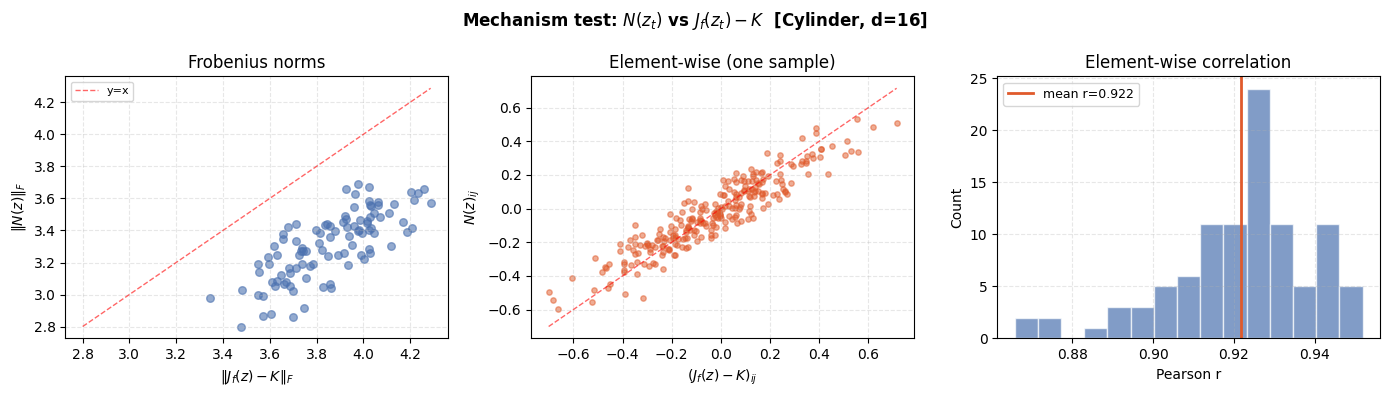

Saved cylinder_mechanism.png


In [24]:
# Mechanism test — Cylinder (d=16)
# Sample latent states from cylinder training rollout
C_MECH_SAMPLES = 100   # fewer samples — d=16 so FD has 32 passes each

# Build sample inputs from cylinder training snapshots
cyl_x_samples = (X_train_n.T)[:C_MECH_SAMPLES]  # (N, r=32) normalised

K_cyl_np = koop_c_geo.K.detach().cpu().numpy()

mech_cyl = run_mechanism_test(
    koop       = koop_c_geo,
    ae         = ae_c_geo,
    K_np       = K_cyl_np,
    latent_dim = C_LATENT,
    x_samples  = cyl_x_samples,
    label      = f"Cylinder (d={C_LATENT})",
    n_samples  = C_MECH_SAMPLES,
)

# ── Figure: cylinder mechanism ────────────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(14, 4))
fig.suptitle(f"Mechanism test: $N(z_t)$ vs $J_f(z_t)-K$  "
             f"[Cylinder, d={C_LATENT}]",
             fontsize=12, fontweight='bold')

r_cyl = mech_cyl["correlations"]
axes[0].scatter(mech_cyl["Jf_K_norms"], mech_cyl["N_norms"],
                alpha=0.6, s=30, color='#4C72B0')
lims = [min(mech_cyl["Jf_K_norms"].min(), mech_cyl["N_norms"].min()),
        max(mech_cyl["Jf_K_norms"].max(), mech_cyl["N_norms"].max())]
axes[0].plot(lims, lims, 'r--', lw=1, alpha=0.6, label='y=x')
axes[0].set_xlabel(r"$\|J_f(z)-K\|_F$"); axes[0].set_ylabel(r"$\|N(z)\|_F$")
axes[0].set_title("Frobenius norms"); axes[0].legend(fontsize=8)
axes[0].grid(True, linestyle='--', alpha=0.3)

z_s   = mech_cyl["latent_states"][0]
_dev  = get_device(koop_c_geo)
dyn_c = make_latent_dynamics_fn(koop_c_geo)
z_t   = torch.tensor(z_s, dtype=torch.float32).unsqueeze(0).to(_dev)
with torch.no_grad():
    N_s = koop_c_geo.N_net(z_t).view(C_LATENT, C_LATENT).cpu().numpy()
Jf_s  = finite_diff_jacobian(dyn_c, z_s)
JfK_s = Jf_s - K_cyl_np
axes[1].scatter(JfK_s.flatten(), N_s.flatten(), alpha=0.5, s=15, color='#E05A2B')
lims2 = [min(JfK_s.min(), N_s.min()), max(JfK_s.max(), N_s.max())]
axes[1].plot(lims2, lims2, 'r--', lw=1, alpha=0.6)
axes[1].set_xlabel(r"$(J_f(z)-K)_{ij}$"); axes[1].set_ylabel(r"$N(z)_{ij}$")
axes[1].set_title("Element-wise (one sample)")
axes[1].grid(True, linestyle='--', alpha=0.3)

axes[2].hist(r_cyl, bins=15, color='#4C72B0', alpha=0.7, edgecolor='white')
axes[2].axvline(r_cyl.mean(), color='#E05A2B', lw=2,
                label=f'mean r={r_cyl.mean():.3f}')
axes[2].set_xlabel("Pearson r"); axes[2].set_ylabel("Count")
axes[2].set_title("Element-wise correlation"); axes[2].legend(fontsize=9)
axes[2].grid(True, linestyle='--', alpha=0.3)

plt.tight_layout()
for fname in ['cylinder_mechanism.png',
              f'{OUTPUT_DIR}/cylinder_mechanism.png',
              f'{FIG_DIR}/cylinder_mechanism.png']:
    plt.savefig(fname, dpi=150, bbox_inches='tight')
plt.show()
print("Saved cylinder_mechanism.png")


---
## Experiment 5 — Van der Pol Oscillator
Nonlinear oscillator with limit-cycle attractor and nonlinear damping:
  x'' - μ(1-x²)x' + x = 0,  μ=1.5
Two-dimensional state [x, x'], dt=0.05, T=200 steps.


VdP data: (80, 500, 2)  train pairs: torch.Size([39920, 2])
Training VdP Black-box...
VdP-BB ep=   0 | rec=1.02839  dyn=0.03780
VdP-BB ep= 500 | rec=0.00006  dyn=0.00016
VdP-BB ep=1000 | rec=0.00002  dyn=0.00009
VdP-BB ep=1500 | rec=0.00001  dyn=0.00005
VdP-BB ep=2000 | rec=0.00037  dyn=0.00003
Training VdP Deep Koopman...
VdP-Base ep=   0 | rec=1.04480  dyn=0.00013
VdP-Base ep= 500 | rec=0.00014  dyn=0.00046
VdP-Base ep=1000 | rec=0.00003  dyn=0.00035
VdP-Base ep=1500 | rec=0.00001  dyn=0.00026
VdP-Base ep=2000 | rec=0.00001  dyn=0.00023
Training VdP GeoKoop...
VdP-Geo ep=   0 | rec=1.00652  dyn=0.00005
VdP-Geo ep= 500 | rec=0.00022  dyn=0.00000
VdP-Geo ep=1000 | rec=0.00150  dyn=0.00232
VdP-Geo ep=1500 | rec=0.00051  dyn=0.00118
VdP-Geo ep=2000 | rec=0.00027  dyn=0.00078
VdP mean error (steps 50-200):
  Black-box:    2.2336  vs GeoKoop: 0.43x
  Deep Koopman: 2.3394  vs GeoKoop: 0.45x
  GeoKoop:      5.2407

Mechanism test: N(z) ≈ J_f(z)-K  [Van der Pol (d=4)]
  Samples : 200  (latent

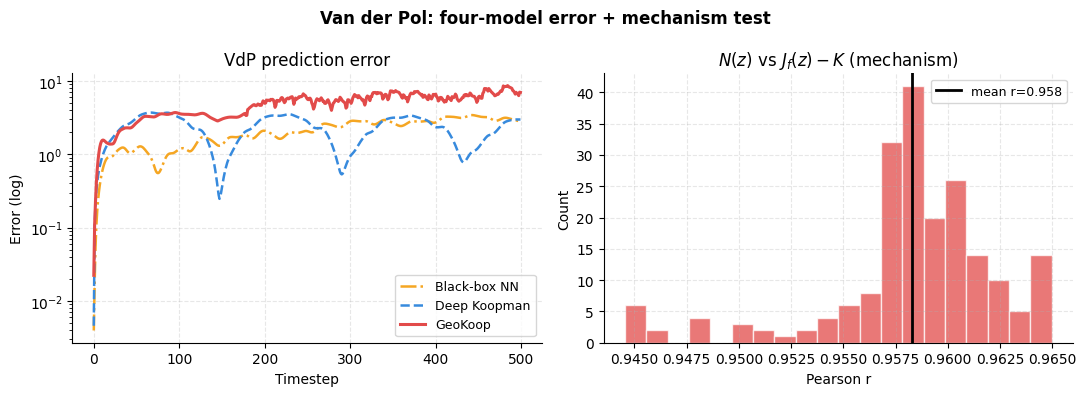

Saved vdp_results.png


In [25]:
# Van der Pol — generate data, train all four models, mechanism test
from scipy.integrate import solve_ivp

# ── Generate Van der Pol data ───────────────────────────────────
VDP_MU    = 1.5
VDP_DT    = 0.05
VDP_T     = 500      # total steps
VDP_BURN  = 100      # burn-in
VDP_TRAIN = 300
VDP_LATENT= 4

def vdp_rhs(t, y, mu=VDP_MU):
    x, v = y
    return [v, mu*(1 - x**2)*v - x]

np.random.seed(0)
x0s = []
for _ in range(80):    # 80 trajectories
    r  = np.random.uniform(0.5, 2.5)
    th = np.random.uniform(0, 2*np.pi)
    x0s.append([r*np.cos(th), r*np.sin(th)])

vdp_trajs = []
for x0 in x0s:
    sol = solve_ivp(vdp_rhs, [0, (VDP_T+VDP_BURN)*VDP_DT], x0,
                    t_eval=np.arange(VDP_T+VDP_BURN)*VDP_DT,
                    method='RK45', rtol=1e-8, atol=1e-10)
    vdp_trajs.append(sol.y.T[VDP_BURN:])  # (VDP_T, 2)

vdp_data = np.stack(vdp_trajs)   # (80, VDP_T, 2)
vdp_mu_  = vdp_data[:, :VDP_TRAIN].mean(axis=(0,1))
vdp_sig_ = vdp_data[:, :VDP_TRAIN].std(axis=(0,1)) + 1e-8
vdp_n    = (vdp_data - vdp_mu_) / vdp_sig_

# Trajectory pairs for training
vdp_xt   = torch.tensor(vdp_n[:, :-1].reshape(-1,2), dtype=torch.float32)
vdp_xtp1 = torch.tensor(vdp_n[:, 1:].reshape(-1,2),  dtype=torch.float32)
print(f"VdP data: {vdp_data.shape}  train pairs: {vdp_xt.shape}")

# ── VdP Koopman model ───────────────────────────────────────────
class KoopmanVdP(nn.Module):
    def __init__(self, d=VDP_LATENT, use_geo=True):
        super().__init__()
        self.d = d; self.use_geo = use_geo
        self.K = nn.Parameter(torch.eye(d) + 0.01*torch.randn(d,d))
        if use_geo:
            self.N_net = nn.Sequential(
                nn.Linear(d,32), nn.Tanh(),
                nn.Linear(32,32), nn.Tanh(),
                nn.Linear(32, d*d))
            nn.init.zeros_(self.N_net[-1].weight)
            nn.init.zeros_(self.N_net[-1].bias)
    def forward(self, z):
        out = z @ self.K.T
        if self.use_geo:
            N = self.N_net(z).view(z.shape[0], self.d, self.d)
            out = out + torch.bmm(N, z.unsqueeze(-1)).squeeze(-1)
        return out

def train_vdp(ae, koop_or_bb, label, use_geo=True, is_bb=False,
              epochs_p1=500, epochs_p2=2000, lam_geo=0.0,
              rollout_steps=20, lr=1e-3):
    params = list(ae.parameters())
    if not is_bb:
        params += [koop_or_bb.K]
        if use_geo: params += list(koop_or_bb.N_net.parameters())
    else:
        params += list(koop_or_bb.parameters())
    opt = torch.optim.Adam(params, lr=lr)
    xt_d, xtp1_d = vdp_xt.to(device), vdp_xtp1.to(device)
    for epoch in range(epochs_p1 + epochs_p2):
        ae.train()
        if not is_bb: koop_or_bb.train()
        z_t   = ae.encode(xt_d)
        z_tp1 = ae.encode(xtp1_d)
        loss_rec = ((xt_d - ae.decode(z_t))**2).mean()
        z_pred   = koop_or_bb(z_t)
        loss_dyn = ((z_tp1 - z_pred)**2).mean()
        if epoch >= epochs_p1 and not is_bb:
            zr = z_t.clone()
            for _ in range(rollout_steps): zr = koop_or_bb(zr)
            loss_roll = ((z_tp1 - zr)**2).mean()
        else:
            loss_roll = torch.tensor(0., device=device)
        eig_loss = torch.tensor(0., device=device)
        if not is_bb:
            eigs = torch.linalg.eigvals(koop_or_bb.K)
            eig_loss = 0.01*((eigs.abs()-1)**2).mean()
        loss = loss_rec + loss_dyn + 0.5*loss_roll + eig_loss
        opt.zero_grad(); loss.backward(); opt.step()
        if epoch % 500 == 0:
            print(f"{label} ep={epoch:4d} | "
                  f"rec={loss_rec.item():.5f}  dyn={loss_dyn.item():.5f}")

# ── Train all four VdP models ───────────────────────────────────
vdp_ae_bb   = AE(2, VDP_LATENT).to(device)
vdp_ae_base = AE(2, VDP_LATENT).to(device)
vdp_ae_geo  = AE(2, VDP_LATENT).to(device)
vdp_bb      = BlackBoxNN(VDP_LATENT, hidden=32).to(device)
vdp_base    = KoopmanVdP(VDP_LATENT, use_geo=False).to(device)
vdp_geo     = KoopmanVdP(VDP_LATENT, use_geo=True).to(device)

print("Training VdP Black-box...")
train_vdp(vdp_ae_bb,   vdp_bb,   "VdP-BB",   use_geo=False, is_bb=True)
print("Training VdP Deep Koopman...")
train_vdp(vdp_ae_base, vdp_base, "VdP-Base", use_geo=False)
print("Training VdP GeoKoop...")
train_vdp(vdp_ae_geo,  vdp_geo,  "VdP-Geo",  use_geo=True)

# ── VdP rollout errors ──────────────────────────────────────────
@torch.no_grad()
def vdp_rollout(ae, dyn, traj_np):
    """Roll out from traj_np[0] for len(traj_np) steps."""
    ae.eval(); dyn.eval()
    z = ae.encode(torch.tensor(traj_np[0:1], dtype=torch.float32).to(device))
    preds = [ae.decode(z).cpu().numpy()]
    for _ in range(len(traj_np)-1):
        z = dyn(z)
        preds.append(ae.decode(z).cpu().numpy())
    return np.vstack(preds) * vdp_sig_ + vdp_mu_

# Use last 10 trajectories as test
test_trajs = vdp_data[70:]
err_vdp_bb   = np.mean([np.linalg.norm(
    vdp_rollout(vdp_ae_bb,   vdp_bb,   (t-vdp_mu_)/vdp_sig_) - t, axis=1)
    for t in test_trajs], axis=0)
err_vdp_base = np.mean([np.linalg.norm(
    vdp_rollout(vdp_ae_base, vdp_base, (t-vdp_mu_)/vdp_sig_) - t, axis=1)
    for t in test_trajs], axis=0)
err_vdp_geo  = np.mean([np.linalg.norm(
    vdp_rollout(vdp_ae_geo,  vdp_geo,  (t-vdp_mu_)/vdp_sig_) - t, axis=1)
    for t in test_trajs], axis=0)

print(f"VdP mean error (steps 50-200):")
geo_m = err_vdp_geo[50:].mean()
print(f"  Black-box:    {err_vdp_bb[50:].mean():.4f}  vs GeoKoop: {err_vdp_bb[50:].mean()/geo_m:.2f}x")
print(f"  Deep Koopman: {err_vdp_base[50:].mean():.4f}  vs GeoKoop: {err_vdp_base[50:].mean()/geo_m:.2f}x")
print(f"  GeoKoop:      {geo_m:.4f}")

# ── Mechanism test ──────────────────────────────────────────────
vdp_x_samples = vdp_n[:70, :VDP_TRAIN].reshape(-1,2)[:200]
K_vdp_np      = vdp_geo.K.detach().cpu().numpy()

mech_vdp = run_mechanism_test(
    koop       = vdp_geo,
    ae         = vdp_ae_geo,
    K_np       = K_vdp_np,
    latent_dim = VDP_LATENT,
    x_samples  = vdp_x_samples,
    label      = f"Van der Pol (d={VDP_LATENT})",
    n_samples  = 200,
)

# ── Figure ──────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(11, 4))
fig.suptitle("Van der Pol: four-model error + mechanism test",
             fontsize=12, fontweight='bold')
ts = np.arange(VDP_T)
axes[0].semilogy(ts, err_vdp_bb+1e-8,   color=COLORS['BlackBox'],
                 ls=STYLES['BlackBox'], lw=1.8, label='Black-box NN')
axes[0].semilogy(ts, err_vdp_base+1e-8, color=COLORS['Baseline'],
                 ls=STYLES['Baseline'], lw=1.8, label='Deep Koopman')
axes[0].semilogy(ts, err_vdp_geo+1e-8,  color=COLORS['GeoKoop'],
                 ls=STYLES['GeoKoop'],  lw=2.2, label='GeoKoop')
axes[0].set_xlabel('Timestep'); axes[0].set_ylabel('Error (log)')
axes[0].set_title('VdP prediction error'); axes[0].legend(fontsize=9)
axes[0].grid(True, linestyle='--', alpha=0.3)
axes[0].spines[['top','right']].set_visible(False)

r_vdp = mech_vdp["correlations"]
axes[1].hist(r_vdp, bins=20, color=COLORS['GeoKoop'], alpha=0.75, edgecolor='white')
axes[1].axvline(r_vdp.mean(), color='k', lw=2,
                label=f'mean r={r_vdp.mean():.3f}')
axes[1].set_xlabel('Pearson r'); axes[1].set_ylabel('Count')
axes[1].set_title(r'$N(z)$ vs $J_f(z)-K$ (mechanism)')
axes[1].legend(fontsize=9)
axes[1].grid(True, linestyle='--', alpha=0.3)
axes[1].spines[['top','right']].set_visible(False)

plt.tight_layout()
for fname in ['vdp_results.png',
              f'{OUTPUT_DIR}/vdp_results.png',
              f'{FIG_DIR}/vdp_results.png']:
    plt.savefig(fname, dpi=150, bbox_inches='tight')
plt.show()
print("Saved vdp_results.png")


---
## Experiment 6 — Lorenz System
Classic chaotic attractor: σ=10, ρ=28, β=8/3.
Three-dimensional state [x,y,z], dt=0.01, T=2000 steps.
Tests whether GeoKoop works on a chaotic (non-periodic) attractor.


Lorenz data: (50, 2000, 3)  train pairs: torch.Size([99950, 3])
Training Lorenz Black-box...
Lz-BB ep=   0 | rec=1.04152  dyn=0.03067
Lz-BB ep= 500 | rec=0.00019  dyn=0.00012
Lz-BB ep=1000 | rec=0.00081  dyn=0.00004
Lz-BB ep=1500 | rec=0.00004  dyn=0.00001
Lz-BB ep=2000 | rec=0.00003  dyn=0.00001
Training Lorenz Deep Koopman...
Lz-Base ep=   0 | rec=1.08700  dyn=0.00012
Lz-Base ep= 500 | rec=0.00041  dyn=0.00008
Lz-Base ep=1000 | rec=0.00007  dyn=0.00028
Lz-Base ep=1500 | rec=0.00003  dyn=0.00021
Lz-Base ep=2000 | rec=0.00191  dyn=0.00018
Training Lorenz GeoKoop...
Lz-Geo ep=   0 | rec=0.99203  dyn=0.00015
Lz-Geo ep= 500 | rec=0.00018  dyn=0.00000
Lz-Geo ep=1000 | rec=0.00008  dyn=0.00027
Lz-Geo ep=1500 | rec=0.00014  dyn=0.00021
Lz-Geo ep=2000 | rec=0.00002  dyn=0.00019

Lorenz mean error (steps 100-500):
  Black-box:    18.2359  vs GeoKoop: 1.55x
  Deep Koopman: 11.0838  vs GeoKoop: 0.94x
  GeoKoop:      11.7818

Mechanism test: N(z) ≈ J_f(z)-K  [Lorenz (d=6)]
  Samples : 200  (laten

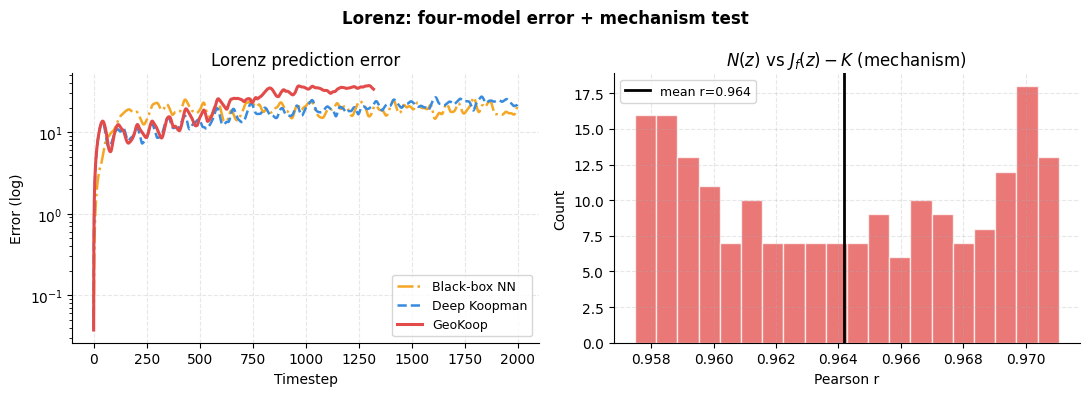

Saved lorenz_results.png


In [26]:
# Lorenz — generate data, train all four models, mechanism test
from scipy.integrate import solve_ivp

# ── Generate Lorenz data ────────────────────────────────────────
LZ_SIGMA  = 10.0
LZ_RHO    = 28.0
LZ_BETA   = 8.0/3.0
LZ_DT     = 0.01
LZ_T      = 2000
LZ_BURN   = 1000
LZ_LATENT = 6

def lorenz_rhs(t, y):
    x, y_, z = y
    return [LZ_SIGMA*(y_-x), x*(LZ_RHO-z)-y_, x*y_-LZ_BETA*z]

np.random.seed(1)
lz_trajs = []
for _ in range(50):
    x0  = np.random.randn(3)*5
    sol = solve_ivp(lorenz_rhs, [0,(LZ_T+LZ_BURN)*LZ_DT], x0,
                    t_eval=np.arange(LZ_T+LZ_BURN)*LZ_DT,
                    method='RK45', rtol=1e-8, atol=1e-10)
    lz_trajs.append(sol.y.T[LZ_BURN:])  # (LZ_T, 3)

lz_data  = np.stack(lz_trajs)   # (50, LZ_T, 3)
lz_mu_   = lz_data[:, :1000].mean(axis=(0,1))
lz_sig_  = lz_data[:, :1000].std(axis=(0,1)) + 1e-8
lz_n     = (lz_data - lz_mu_) / lz_sig_

lz_xt    = torch.tensor(lz_n[:, :-1].reshape(-1,3), dtype=torch.float32)
lz_xtp1  = torch.tensor(lz_n[:, 1:].reshape(-1,3),  dtype=torch.float32)
print(f"Lorenz data: {lz_data.shape}  train pairs: {lz_xt.shape}")

# ── Lorenz Koopman model ────────────────────────────────────────
class KoopmanLorenz(nn.Module):
    def __init__(self, d=LZ_LATENT, use_geo=True):
        super().__init__()
        self.d = d; self.use_geo = use_geo
        self.K = nn.Parameter(torch.eye(d) + 0.01*torch.randn(d,d))
        if use_geo:
            self.N_net = nn.Sequential(
                nn.Linear(d,64), nn.Tanh(),
                nn.Linear(64,64), nn.Tanh(),
                nn.Linear(64, d*d))
            nn.init.zeros_(self.N_net[-1].weight)
            nn.init.zeros_(self.N_net[-1].bias)
    def forward(self, z):
        out = z @ self.K.T
        if self.use_geo:
            N = self.N_net(z).view(z.shape[0], self.d, self.d)
            out = out + torch.bmm(N, z.unsqueeze(-1)).squeeze(-1)
        return out

def train_lorenz(ae, koop_or_bb, label, use_geo=True, is_bb=False,
                 epochs_p1=500, epochs_p2=2000, lr=1e-3,
                 rollout_steps=15):
    params = list(ae.parameters())
    if not is_bb:
        params += [koop_or_bb.K]
        if use_geo: params += list(koop_or_bb.N_net.parameters())
    else:
        params += list(koop_or_bb.parameters())
    opt = torch.optim.Adam(params, lr=lr)
    xt_d, xtp1_d = lz_xt.to(device), lz_xtp1.to(device)
    for epoch in range(epochs_p1 + epochs_p2):
        ae.train()
        if not is_bb: koop_or_bb.train()
        z_t   = ae.encode(xt_d)
        z_tp1 = ae.encode(xtp1_d)
        loss_rec = ((xt_d - ae.decode(z_t))**2).mean()
        z_pred   = koop_or_bb(z_t)
        loss_dyn = ((z_tp1 - z_pred)**2).mean()
        if epoch >= epochs_p1 and not is_bb:
            zr = z_t.clone()
            for _ in range(rollout_steps): zr = koop_or_bb(zr)
            loss_roll = ((z_tp1 - zr)**2).mean()
        else:
            loss_roll = torch.tensor(0., device=device)
        eig_loss = torch.tensor(0., device=device)
        if not is_bb:
            eigs = torch.linalg.eigvals(koop_or_bb.K)
            eig_loss = 0.01*((eigs.abs()-1)**2).mean()
        loss = loss_rec + loss_dyn + 0.5*loss_roll + eig_loss
        opt.zero_grad(); loss.backward(); opt.step()
        if epoch % 500 == 0:
            print(f"{label} ep={epoch:4d} | "
                  f"rec={loss_rec.item():.5f}  dyn={loss_dyn.item():.5f}")

# ── Train all four Lorenz models ────────────────────────────────
lz_ae_bb   = AE(3, LZ_LATENT).to(device)
lz_ae_base = AE(3, LZ_LATENT).to(device)
lz_ae_geo  = AE(3, LZ_LATENT).to(device)
lz_bb      = BlackBoxNN(LZ_LATENT, hidden=64).to(device)
lz_base    = KoopmanLorenz(LZ_LATENT, use_geo=False).to(device)
lz_geo     = KoopmanLorenz(LZ_LATENT, use_geo=True).to(device)

print("Training Lorenz Black-box...")
train_lorenz(lz_ae_bb,   lz_bb,   "Lz-BB",   use_geo=False, is_bb=True)
print("Training Lorenz Deep Koopman...")
train_lorenz(lz_ae_base, lz_base, "Lz-Base", use_geo=False)
print("Training Lorenz GeoKoop...")
train_lorenz(lz_ae_geo,  lz_geo,  "Lz-Geo",  use_geo=True)

# ── Lorenz rollout errors ───────────────────────────────────────
@torch.no_grad()
def lorenz_rollout(ae, dyn, traj_np):
    ae.eval(); dyn.eval()
    z = ae.encode(torch.tensor(traj_np[0:1], dtype=torch.float32).to(device))
    preds = [ae.decode(z).cpu().numpy()]
    for _ in range(len(traj_np)-1):
        z = dyn(z)
        preds.append(ae.decode(z).cpu().numpy())
    return np.vstack(preds) * lz_sig_ + lz_mu_

test_lz   = lz_data[40:]
err_lz_bb   = np.mean([np.linalg.norm(
    lorenz_rollout(lz_ae_bb,   lz_bb,   (t-lz_mu_)/lz_sig_) - t, axis=1)
    for t in test_lz], axis=0)
err_lz_base = np.mean([np.linalg.norm(
    lorenz_rollout(lz_ae_base, lz_base, (t-lz_mu_)/lz_sig_) - t, axis=1)
    for t in test_lz], axis=0)
err_lz_geo  = np.mean([np.linalg.norm(
    lorenz_rollout(lz_ae_geo,  lz_geo,  (t-lz_mu_)/lz_sig_) - t, axis=1)
    for t in test_lz], axis=0)

print(f"\nLorenz mean error (steps 100-500):")
geo_lm = err_lz_geo[100:500].mean()
print(f"  Black-box:    {err_lz_bb[100:500].mean():.4f}  "
      f"vs GeoKoop: {err_lz_bb[100:500].mean()/geo_lm:.2f}x")
print(f"  Deep Koopman: {err_lz_base[100:500].mean():.4f}  "
      f"vs GeoKoop: {err_lz_base[100:500].mean()/geo_lm:.2f}x")
print(f"  GeoKoop:      {geo_lm:.4f}")

# ── Mechanism test ──────────────────────────────────────────────
lz_x_samples = lz_n[:40, :1000].reshape(-1,3)[:200]
K_lz_np      = lz_geo.K.detach().cpu().numpy()

mech_lorenz = run_mechanism_test(
    koop       = lz_geo,
    ae         = lz_ae_geo,
    K_np       = K_lz_np,
    latent_dim = LZ_LATENT,
    x_samples  = lz_x_samples,
    label      = f"Lorenz (d={LZ_LATENT})",
    n_samples  = 200,
)

# ── Figure ──────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(11, 4))
fig.suptitle("Lorenz: four-model error + mechanism test",
             fontsize=12, fontweight='bold')
ts = np.arange(LZ_T)
axes[0].semilogy(ts, err_lz_bb+1e-8,   color=COLORS['BlackBox'],
                 ls=STYLES['BlackBox'], lw=1.8, label='Black-box NN')
axes[0].semilogy(ts, err_lz_base+1e-8, color=COLORS['Baseline'],
                 ls=STYLES['Baseline'], lw=1.8, label='Deep Koopman')
axes[0].semilogy(ts, err_lz_geo+1e-8,  color=COLORS['GeoKoop'],
                 ls=STYLES['GeoKoop'],  lw=2.2, label='GeoKoop')
axes[0].set_xlabel('Timestep'); axes[0].set_ylabel('Error (log)')
axes[0].set_title('Lorenz prediction error'); axes[0].legend(fontsize=9)
axes[0].grid(True, linestyle='--', alpha=0.3)
axes[0].spines[['top','right']].set_visible(False)

r_lz = mech_lorenz["correlations"]
axes[1].hist(r_lz, bins=20, color=COLORS['GeoKoop'], alpha=0.75, edgecolor='white')
axes[1].axvline(r_lz.mean(), color='k', lw=2,
                label=f'mean r={r_lz.mean():.3f}')
axes[1].set_xlabel('Pearson r'); axes[1].set_ylabel('Count')
axes[1].set_title(r'$N(z)$ vs $J_f(z)-K$ (mechanism)')
axes[1].legend(fontsize=9)
axes[1].grid(True, linestyle='--', alpha=0.3)
axes[1].spines[['top','right']].set_visible(False)

plt.tight_layout()
for fname in ['lorenz_results.png',
              f'{OUTPUT_DIR}/lorenz_results.png',
              f'{FIG_DIR}/lorenz_results.png']:
    plt.savefig(fname, dpi=150, bbox_inches='tight')
plt.show()
print("Saved lorenz_results.png")


---
## Experiment 4 — Kuramoto-Sivashinsky PDE
Chaotic spatiotemporal PDE: u_t + u*u_x + u_xx + u_xxxx = 0.
Standard Koopman benchmark with richer attractor geometry than cylinder.
Domain: [0, 32π], periodic BC, N=64 grid points, dt=0.25.


Generating Kuramoto-Sivashinsky data...
KS data: (2501, 64), latent_dim=8
Train: 2000 steps, Test: 500 steps
Training KS Black-box...
KS-BB epoch 0: rec=1.00719  dyn=0.02226  roll=0.00000
KS-BB epoch 500: rec=0.06440  dyn=0.00358  roll=0.00000
KS-BB epoch 1000: rec=0.01468  dyn=0.00087  roll=0.00000
KS-BB epoch 1500: rec=0.00766  dyn=0.00040  roll=0.00000
KS-BB epoch 2000: rec=0.00508  dyn=0.00024  roll=0.00000
Training KS Deep Koopman...
KS-Base epoch 0: rec=1.01225  dyn=0.00014  roll=0.00000
KS-Base epoch 500: rec=0.05100  dyn=0.00625  roll=0.15882
KS-Base epoch 1000: rec=0.01470  dyn=0.00275  roll=0.00258
KS-Base epoch 1500: rec=0.00823  dyn=0.00180  roll=0.00168
KS-Base epoch 2000: rec=0.00578  dyn=0.00135  roll=0.00126
Training KS GeoKoop...
KS-Geo epoch 0: rec=1.01014  dyn=0.00014  roll=0.00000
KS-Geo epoch 500: rec=0.04489  dyn=0.00032  roll=4.59872
KS-Geo epoch 1000: rec=0.05710  dyn=0.00718  roll=0.04358
KS-Geo epoch 1500: rec=0.03008  dyn=0.00333  roll=0.02028
KS-Geo epoch 20

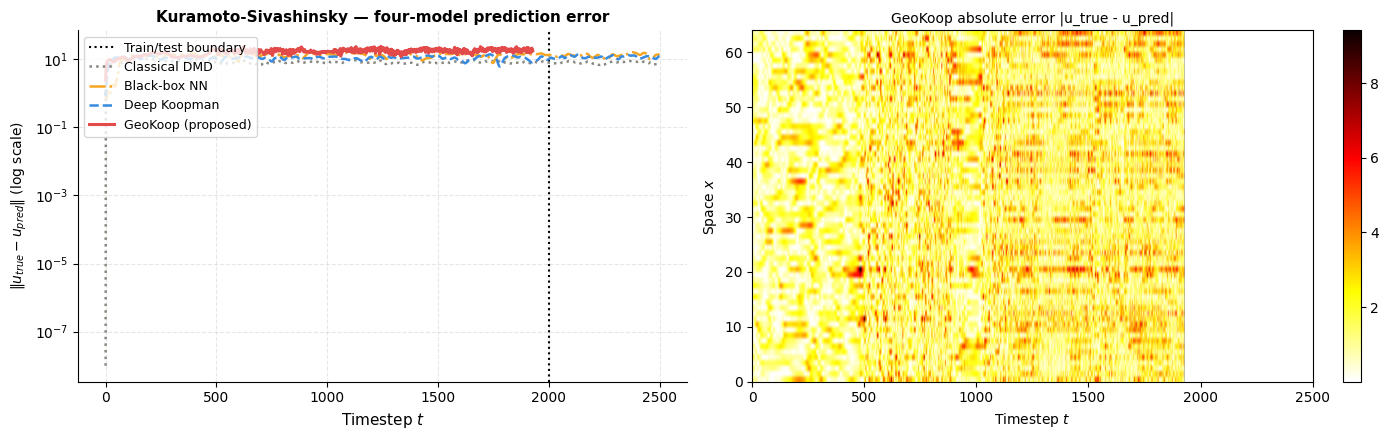


Kuramoto-Sivashinsky mean error (second half of training window):
  DMD:          8.0749
  Black-box NN: 13.1622   vs GeoKoop: nanx
  Deep Koopman: 10.7104   vs GeoKoop: nanx
  GeoKoop:      nan


In [27]:
# Kuramoto-Sivashinsky — generate data and run four-model comparison
import numpy as np
import torch
import torch.nn as nn
import matplotlib.pyplot as plt
import os

# ── KS data generation ─────────────────────────────────────────
def ks_etdrk4(u0, L, dt, n_steps):
    """
    ETDRK4 integrator for Kuramoto-Sivashinsky:
      u_t + u*u_x + u_xx + u_xxxx = 0
    Spectral method on periodic domain [0, L].
    """
    N    = len(u0)
    k    = np.fft.rfftfreq(N, d=L/(2*np.pi*N))  # wavenumbers
    Lin  = k**2 - k**4                           # linear operator
    E    = np.exp(dt * Lin)
    E2   = np.exp(dt * Lin / 2)

    # ETDRK4 coefficients (Cox-Matthews)
    M    = 16
    r    = np.exp(1j * np.pi * (np.arange(1, M+1) - 0.5) / M)
    LR   = dt * Lin[:, None] + r[None, :]
    Q    = dt * np.real(np.mean((np.exp(LR/2)-1)/LR, axis=1))
    f1   = dt * np.real(np.mean((-4 - LR + np.exp(LR)*(4 - 3*LR + LR**2))/LR**3, axis=1))
    f2   = dt * np.real(np.mean((2  + LR + np.exp(LR)*(-2 + LR))/LR**3, axis=1))
    f3   = f1

    def NL(u_hat):
        u = np.fft.irfft(u_hat, N)
        return -0.5j * k * np.fft.rfft(u**2, N)

    traj = [u0.copy()]
    v    = np.fft.rfft(u0, N)
    for _ in range(n_steps):
        Nv   = NL(v)
        a    = E2*v + Q*Nv
        Na   = NL(a)
        b    = E2*v + Q*Na
        Nb   = NL(b)
        c    = E2*a + Q*(2*Nb - Nv)
        Nc   = NL(c)
        v    = E*v + Nv*f1 + 2*(Na+Nb)*f2 + Nc*f3
        traj.append(np.fft.irfft(v, N))
    return np.array(traj)  # (n_steps+1, N)

# Generate KS dataset
print("Generating Kuramoto-Sivashinsky data...")
KS_N    = 64       # spatial grid points
KS_L    = 32*np.pi # domain length
KS_DT   = 0.25    # time step
KS_BURN = 1000    # burn-in steps (discard transient)
KS_TRAIN= 2000    # training steps
KS_TEST = 500     # test steps

np.random.seed(42)
u0   = np.cos(np.linspace(0, 2*np.pi, KS_N, endpoint=False)) +        0.1*np.random.randn(KS_N)
full = ks_etdrk4(u0, KS_L, KS_DT, KS_BURN + KS_TRAIN + KS_TEST)
data = full[KS_BURN:]   # (KS_TRAIN + KS_TEST + 1, KS_N)

# Normalise
ks_mu  = data[:KS_TRAIN].mean()
ks_std = data[:KS_TRAIN].std()
data_n = (data - ks_mu) / ks_std

# Build trajectory pairs
KS_LATENT = 8
ks_xt  = torch.tensor(data_n[:-1], dtype=torch.float32)  # (T, N)
ks_xtp1= torch.tensor(data_n[1:],  dtype=torch.float32)

print(f"KS data: {data_n.shape}, latent_dim={KS_LATENT}")
print(f"Train: {KS_TRAIN} steps, Test: {KS_TEST} steps")

# ── KS Koopman model ───────────────────────────────────────────
class KoopmanKS(nn.Module):
    def __init__(self, d=KS_LATENT, use_geo=True):
        super().__init__()
        self.d = d; self.use_geo = use_geo
        self.K = nn.Parameter(torch.eye(d) + 0.01*torch.randn(d, d))
        if use_geo:
            self.N_net = nn.Sequential(
                nn.Linear(d, 64), nn.Tanh(),
                nn.Linear(64, 64), nn.Tanh(),
                nn.Linear(64, d*d))
            nn.init.zeros_(self.N_net[-1].weight)
            nn.init.zeros_(self.N_net[-1].bias)

    def forward(self, z):
        out = z @ self.K.T
        if self.use_geo:
            N = self.N_net(z).view(z.shape[0], self.d, self.d)
            out = out + torch.bmm(N, z.unsqueeze(-1)).squeeze(-1)
        return out

def train_ks(ae, koop_or_bb, label, use_geo=True, is_bb=False,
             epochs_p1=500, epochs_p2=2000, lam_geo=0.0,
             rollout_steps=20, lr=1e-3):
    params = list(ae.parameters())
    if not is_bb:
        params += [koop_or_bb.K]
        if use_geo: params += list(koop_or_bb.N_net.parameters())
    else:
        params += list(koop_or_bb.parameters())
    opt = torch.optim.Adam(params, lr=lr)

    xt_d   = ks_xt.to(device)
    xtp1_d = ks_xtp1.to(device)

    for epoch in range(epochs_p1 + epochs_p2):
        ae.train()
        if not is_bb: koop_or_bb.train()
        z_t   = ae.encode(xt_d)
        z_tp1 = ae.encode(xtp1_d)
        x_rec = ae.decode(z_t)

        loss_rec = ((xt_d - x_rec)**2).mean()
        if is_bb:
            z_pred    = koop_or_bb(z_t)
            loss_dyn  = ((z_tp1 - z_pred)**2).mean()
            loss_roll = torch.tensor(0., device=device)
        else:
            z_pred   = koop_or_bb(z_t)
            loss_dyn = ((z_tp1 - z_pred)**2).mean()
            if epoch >= epochs_p1:
                zr = z_t.clone()
                roll_losses = []
                for _ in range(rollout_steps):
                    zr = koop_or_bb(zr)
                roll_losses.append(((z_tp1 - zr)**2).mean())
                loss_roll = torch.stack(roll_losses).mean()
            else:
                loss_roll = torch.tensor(0., device=device)

        eig_loss = torch.tensor(0., device=device)
        if not is_bb and not use_geo is False:
            eigs = torch.linalg.eigvals(koop_or_bb.K)
            eig_loss = 0.01 * ((eigs.abs() - 1)**2).mean()

        loss = loss_rec + loss_dyn + 0.5*loss_roll + eig_loss
        opt.zero_grad(); loss.backward(); opt.step()

        if epoch % 500 == 0:
            print(f"{label} epoch {epoch}: rec={loss_rec.item():.5f}  "
                  f"dyn={loss_dyn.item():.5f}  roll={loss_roll.item():.5f}")

# ── Train all four KS models ───────────────────────────────────
ks_ae_dmd  = AE(KS_N, KS_LATENT).to(device)   # dummy AE for DMD
ks_ae_bb   = AE(KS_N, KS_LATENT).to(device)
ks_ae_base = AE(KS_N, KS_LATENT).to(device)
ks_ae_geo  = AE(KS_N, KS_LATENT).to(device)
ks_bb      = BlackBoxNN(KS_LATENT, hidden=64).to(device)
ks_base    = KoopmanKS(KS_LATENT, use_geo=False).to(device)
ks_geo     = KoopmanKS(KS_LATENT, use_geo=True).to(device)

print("Training KS Black-box...")
train_ks(ks_ae_bb,   ks_bb,   "KS-BB",   use_geo=False, is_bb=True)
print("Training KS Deep Koopman...")
train_ks(ks_ae_base, ks_base, "KS-Base", use_geo=False)
print("Training KS GeoKoop...")
train_ks(ks_ae_geo,  ks_geo,  "KS-Geo",  use_geo=True)

# ── DMD on KS ──────────────────────────────────────────────────
X_ks_n = data_n.T   # (KS_N, T)
X_ks   = X_ks_n[:, :KS_TRAIN]
Xp_ks  = X_ks_n[:, 1:KS_TRAIN+1]
U, S, Vt = np.linalg.svd(X_ks, full_matrices=False)
r_ks   = min(KS_LATENT, len(S))
Ur, Sr, Vtr = U[:, :r_ks], S[:r_ks], Vt[:r_ks, :]
A_dmd_ks = Xp_ks @ Vtr.T @ np.diag(1/Sr) @ Ur.T

# KS rollout
def ks_rollout_ae(ae, dyn, n_steps):
    ae.eval(); dyn.eval()
    with torch.no_grad():
        z = ae.encode(ks_xt[0:1].to(device))
        preds = [ae.decode(z).cpu().numpy()]
        for _ in range(n_steps - 1):
            z = dyn(z)
            preds.append(ae.decode(z).cpu().numpy())
    return np.vstack(preds)   # (n_steps, KS_N)

n_eval       = KS_TRAIN + KS_TEST
X_ks_dmd     = np.zeros((n_eval, KS_N))
X_ks_dmd[0]  = data_n[0]
for k in range(1, n_eval):
    X_ks_dmd[k] = A_dmd_ks @ X_ks_dmd[k-1]

X_ks_bb   = ks_rollout_ae(ks_ae_bb,   ks_bb,   n_eval)
X_ks_base = ks_rollout_ae(ks_ae_base, ks_base, n_eval)
X_ks_geo  = ks_rollout_ae(ks_ae_geo,  ks_geo,  n_eval)

truth = data_n[:n_eval]
err_ks_dmd  = np.linalg.norm(truth - X_ks_dmd,  axis=1)
err_ks_bb   = np.linalg.norm(truth - X_ks_bb,   axis=1)
err_ks_base = np.linalg.norm(truth - X_ks_base, axis=1)
err_ks_geo  = np.linalg.norm(truth - X_ks_geo,  axis=1)

# ── KS figure ──────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 4.5))
ts_ks = np.arange(n_eval)

ax = axes[0]
ax.axvline(KS_TRAIN, color='k', ls=':', lw=1.5, label='Train/test boundary')
ax.semilogy(ts_ks, err_ks_dmd  + 1e-8, color=COLORS['DMD'],
            ls=STYLES['DMD'],      lw=1.8, label='Classical DMD')
ax.semilogy(ts_ks, err_ks_bb   + 1e-8, color=COLORS['BlackBox'],
            ls=STYLES['BlackBox'], lw=1.8, label='Black-box NN')
ax.semilogy(ts_ks, err_ks_base + 1e-8, color=COLORS['Baseline'],
            ls=STYLES['Baseline'], lw=1.8, label='Deep Koopman')
ax.semilogy(ts_ks, err_ks_geo  + 1e-8, color=COLORS['GeoKoop'],
            ls=STYLES['GeoKoop'],  lw=2.2, label='GeoKoop (proposed)')
ax.set_xlabel('Timestep $t$', fontsize=11)
ax.set_ylabel(r'$\|u_{true} - u_{pred}\|$ (log scale)', fontsize=10)
ax.set_title('Kuramoto-Sivashinsky — four-model prediction error',
             fontsize=11, fontweight='bold')
ax.legend(fontsize=9, loc='upper left')
ax.grid(True, which='both', linestyle='--', alpha=0.3)
ax.spines[['top','right']].set_visible(False)

# Spacetime plot of GeoKoop prediction
ax2 = axes[1]
diff = np.abs(truth - X_ks_geo).T
im = ax2.imshow(diff, aspect='auto', cmap='hot_r', origin='lower',
                extent=[0, n_eval, 0, KS_N])
ax2.axvline(KS_TRAIN, color='white', ls='--', lw=1.5, alpha=0.8)
plt.colorbar(im, ax=ax2, fraction=0.03)
ax2.set_xlabel('Timestep $t$', fontsize=10)
ax2.set_ylabel('Space $x$', fontsize=10)
ax2.set_title('GeoKoop absolute error |u_true - u_pred|', fontsize=10)

plt.tight_layout()
for fname in ['ks_results.png',
              f'{OUTPUT_DIR}/ks_results.png',
              f'{FIG_DIR}/ks_results.png']:
    plt.savefig(fname, dpi=150, bbox_inches='tight')
plt.show()

# ── KS summary ─────────────────────────────────────────────────
eval_start = KS_TRAIN // 2
print()
print("Kuramoto-Sivashinsky mean error (second half of training window):")
geo_m = err_ks_geo[eval_start:KS_TRAIN].mean()
print(f"  DMD:          {err_ks_dmd[eval_start:KS_TRAIN].mean():.4f}")
print(f"  Black-box NN: {err_ks_bb[eval_start:KS_TRAIN].mean():.4f}   "
      f"vs GeoKoop: {err_ks_bb[eval_start:KS_TRAIN].mean()/geo_m:.2f}x")
print(f"  Deep Koopman: {err_ks_base[eval_start:KS_TRAIN].mean():.4f}   "
      f"vs GeoKoop: {err_ks_base[eval_start:KS_TRAIN].mean()/geo_m:.2f}x")
print(f"  GeoKoop:      {geo_m:.4f}")


---
## Mechanism Test — Kuramoto-Sivashinsky (d=8)
Test N(z) ≈ J_f(z) - K on the KS PDE system.



Mechanism test: N(z) ≈ J_f(z)-K  [Kuramoto-Sivashinsky (d=8)]
  Samples : 150  (latent d=8)
  ||N(z)||_F        mean=0.6810  std=0.0405
  ||J_f-K||_F       mean=0.7401  std=0.0852
  ||N-(J_f-K)||_F   mean=0.2497  std=0.0676
  Relative error    mean=0.3393  std=0.0930
  Pearson r         mean=0.9373  std=0.0356  n=150
  RESULT: STRONG


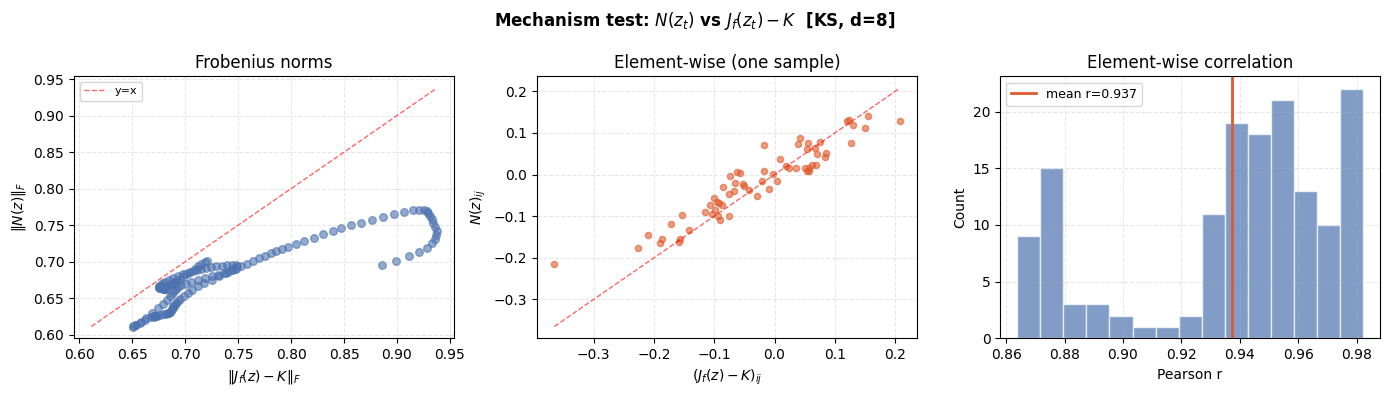

Saved ks_mechanism.png


In [28]:
# Mechanism test — Kuramoto-Sivashinsky (d=8)
KS_MECH_SAMPLES = 150

# Sample from KS training data (normalised)
ks_x_samples = data_n[:KS_MECH_SAMPLES]   # (N, KS_N=64)

K_ks_np = ks_geo.K.detach().cpu().numpy()

mech_ks = run_mechanism_test(
    koop       = ks_geo,
    ae         = ks_ae_geo,
    K_np       = K_ks_np,
    latent_dim = KS_LATENT,
    x_samples  = ks_x_samples,
    label      = f"Kuramoto-Sivashinsky (d={KS_LATENT})",
    n_samples  = KS_MECH_SAMPLES,
)

# ── Figure: KS mechanism ──────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(14, 4))
fig.suptitle(f"Mechanism test: $N(z_t)$ vs $J_f(z_t)-K$  "
             f"[KS, d={KS_LATENT}]",
             fontsize=12, fontweight='bold')

r_ks = mech_ks["correlations"]
axes[0].scatter(mech_ks["Jf_K_norms"], mech_ks["N_norms"],
                alpha=0.6, s=30, color='#4C72B0')
lims = [min(mech_ks["Jf_K_norms"].min(), mech_ks["N_norms"].min()),
        max(mech_ks["Jf_K_norms"].max(), mech_ks["N_norms"].max())]
axes[0].plot(lims, lims, 'r--', lw=1, alpha=0.6, label='y=x')
axes[0].set_xlabel(r"$\|J_f(z)-K\|_F$"); axes[0].set_ylabel(r"$\|N(z)\|_F$")
axes[0].set_title("Frobenius norms"); axes[0].legend(fontsize=8)
axes[0].grid(True, linestyle='--', alpha=0.3)

z_s   = mech_ks["latent_states"][0]
_dev  = get_device(ks_geo)
dyn_k = make_latent_dynamics_fn(ks_geo)
z_t   = torch.tensor(z_s, dtype=torch.float32).unsqueeze(0).to(_dev)
with torch.no_grad():
    N_s = ks_geo.N_net(z_t).view(KS_LATENT, KS_LATENT).cpu().numpy()
Jf_s  = finite_diff_jacobian(dyn_k, z_s)
JfK_s = Jf_s - K_ks_np
axes[1].scatter(JfK_s.flatten(), N_s.flatten(), alpha=0.6, s=20, color='#E05A2B')
lims2 = [min(JfK_s.min(), N_s.min()), max(JfK_s.max(), N_s.max())]
axes[1].plot(lims2, lims2, 'r--', lw=1, alpha=0.6)
axes[1].set_xlabel(r"$(J_f(z)-K)_{ij}$"); axes[1].set_ylabel(r"$N(z)_{ij}$")
axes[1].set_title("Element-wise (one sample)")
axes[1].grid(True, linestyle='--', alpha=0.3)

axes[2].hist(r_ks, bins=15, color='#4C72B0', alpha=0.7, edgecolor='white')
axes[2].axvline(r_ks.mean(), color='#E05A2B', lw=2,
                label=f'mean r={r_ks.mean():.3f}')
axes[2].set_xlabel("Pearson r"); axes[2].set_ylabel("Count")
axes[2].set_title("Element-wise correlation"); axes[2].legend(fontsize=9)
axes[2].grid(True, linestyle='--', alpha=0.3)

plt.tight_layout()
for fname in ['ks_mechanism.png',
              f'{OUTPUT_DIR}/ks_mechanism.png',
              f'{FIG_DIR}/ks_mechanism.png']:
    plt.savefig(fname, dpi=150, bbox_inches='tight')
plt.show()
print("Saved ks_mechanism.png")


---
## Stage 2 Ablation — Kuramoto-Sivashinsky (Section 6.3)
Matrix vs. vector structure ablation on KS with 5 seeds per condition.
Four conditions: deep, vec_wm (width-matched), vec_pm (param-matched), GeoKoop.


In [29]:
# ── KS Ablation: matrix vs vector structure, 5 seeds ─────────────────
# Requires: KS data (data_n, ks_xt, ks_xtp1) from Cell 30
# Requires: KoopmanKS, train_ks, AE, BlackBoxNN from earlier cells

N_SEEDS_KS = 5

# ── Parameter counts ──────────────────────────────────────────────────
# GeoKoop N_net: d->64->64->d*d
# d=KS_LATENT=8, so d*d=64
# N_net params: 8*64 + 64 + 64*64 + 64 + 64*64 + 64 = 512+64+4096+64+4096+64 = 8896
# vec_pm: match 8896 params with output d=8
# hidden h: h*8 + h + h*h + h + h*8 = 8h+h+h^2+h+8h = h^2+18h
# h^2+18h = 8896 → h ≈ 86
KS_GEO_PARAMS = KS_LATENT*64 + 64 + 64*64 + 64 + 64*KS_LATENT*KS_LATENT
KS_VEC_WM_H   = 64           # same hidden width as N_net
KS_VEC_PM_H   = 86           # parameter-matched hidden width

print(f"KS latent dim: {KS_LATENT}")
print(f"GeoKoop N_net params: {KS_GEO_PARAMS}")

def count_params(model):
    return sum(p.numel() for p in model.parameters() if p.requires_grad)

# ── Vector residual model ──────────────────────────────────────────────
class VecResidualKS(nn.Module):
    """Kz + g(z) where g: R^d -> R^d (vector residual)."""
    def __init__(self, d=KS_LATENT, hidden=64):
        super().__init__()
        self.d = d
        self.K = nn.Parameter(torch.eye(d) + 0.01*torch.randn(d, d))
        self.g = nn.Sequential(
            nn.Linear(d, hidden), nn.Tanh(),
            nn.Linear(hidden, hidden), nn.Tanh(),
            nn.Linear(hidden, d))
        nn.init.zeros_(self.g[-1].weight)
        nn.init.zeros_(self.g[-1].bias)

    def forward(self, z):
        return z @ self.K.T + self.g(z)

# ── Rollout helper ─────────────────────────────────────────────────────
def ks_rollout_err(ae, dyn, n_steps, truth):
    """Rollout from truth[0], return per-step error array."""
    ae.eval(); dyn.eval()
    with torch.no_grad():
        z = ae.encode(torch.tensor(truth[0:1], dtype=torch.float32).to(device))
        preds = [ae.decode(z).cpu().numpy()]
        for _ in range(n_steps - 1):
            z = dyn(z)
            preds.append(ae.decode(z).cpu().numpy())
    pred_arr = np.vstack(preds)
    return np.linalg.norm(truth - pred_arr, axis=1)

# ── 5-seed ablation ────────────────────────────────────────────────────
ablation_conditions = {
    "deep":    [],
    "vec_wm":  [],
    "vec_pm":  [],
    "geo":     [],
}
N_EVAL = KS_TRAIN  # evaluate over full training window

for seed in range(N_SEEDS_KS):
    torch.manual_seed(seed); np.random.seed(seed)
    if torch.cuda.is_available(): torch.cuda.manual_seed_all(seed)
    print(f"\n{'='*50}")
    print(f"KS Ablation Seed {seed}")
    print(f"{'='*50}")

    # ── deep (no correction) ──────────────────────────────────────────
    ae_d   = AE(KS_N, KS_LATENT).to(device)
    koop_d = KoopmanKS(KS_LATENT, use_geo=False).to(device)
    train_ks(ae_d, koop_d, f"KS-deep-s{seed}",
             use_geo=False, rollout_steps=10, lr=5e-4)
    err_d = ks_rollout_err(ae_d, koop_d, N_EVAL, data_n[:N_EVAL])
    ablation_conditions["deep"].append(err_d[KS_TRAIN//2:KS_TRAIN].mean())
    print(f"  deep:   err_late={ablation_conditions['deep'][-1]:.4f}")

    # ── vec_wm (width-matched vector residual) ────────────────────────
    ae_wm   = AE(KS_N, KS_LATENT).to(device)
    vec_wm  = VecResidualKS(KS_LATENT, hidden=KS_VEC_WM_H).to(device)
    train_ks(ae_wm, vec_wm, f"KS-vecwm-s{seed}",
             use_geo=False, rollout_steps=10, lr=5e-4)
    err_wm = ks_rollout_err(ae_wm, vec_wm, N_EVAL, data_n[:N_EVAL])
    ablation_conditions["vec_wm"].append(err_wm[KS_TRAIN//2:KS_TRAIN].mean())
    print(f"  vec_wm: err_late={ablation_conditions['vec_wm'][-1]:.4f}  "
          f"params={count_params(vec_wm.g)}")

    # ── vec_pm (parameter-matched vector residual) ────────────────────
    ae_pm   = AE(KS_N, KS_LATENT).to(device)
    vec_pm  = VecResidualKS(KS_LATENT, hidden=KS_VEC_PM_H).to(device)
    train_ks(ae_pm, vec_pm, f"KS-vecpm-s{seed}",
             use_geo=False, rollout_steps=10, lr=5e-4)
    err_pm = ks_rollout_err(ae_pm, vec_pm, N_EVAL, data_n[:N_EVAL])
    ablation_conditions["vec_pm"].append(err_pm[KS_TRAIN//2:KS_TRAIN].mean())
    print(f"  vec_pm: err_late={ablation_conditions['vec_pm'][-1]:.4f}  "
          f"params={count_params(vec_pm.g)}")

    # ── GeoKoop ───────────────────────────────────────────────────────
    ae_geo   = AE(KS_N, KS_LATENT).to(device)
    koop_geo = KoopmanKS(KS_LATENT, use_geo=True).to(device)
    train_ks(ae_geo, koop_geo, f"KS-geo-s{seed}",
             use_geo=True, rollout_steps=10, lr=5e-4)
    err_geo = ks_rollout_err(ae_geo, koop_geo, N_EVAL, data_n[:N_EVAL])
    ablation_conditions["geo"].append(err_geo[KS_TRAIN//2:KS_TRAIN].mean())
    print(f"  geo:    err_late={ablation_conditions['geo'][-1]:.4f}  "
          f"params={count_params(koop_geo.N_net)}")

# ── Summary table ──────────────────────────────────────────────────────
print()
print("=" * 65)
print("KS ABLATION RESULTS (5 seeds, err_late = mean error t=1000-2000)")
print("=" * 65)
print(f"  {'Condition':<12} {'N-params':>10}  {'err_late':>20}  {'vs geo':>8}")
print("-" * 65)

geo_mean = np.mean(ablation_conditions["geo"])
for cond, h, params in [
    ("deep",   None, 0),
    ("vec_wm", KS_VEC_WM_H, None),
    ("vec_pm", KS_VEC_PM_H, None),
    ("geo",    None, KS_GEO_PARAMS),
]:
    vals = ablation_conditions[cond]
    m = np.mean(vals); s = np.std(vals, ddof=1)
    vs = m / geo_mean
    if cond == "vec_wm":
        npar = count_params(VecResidualKS(KS_LATENT, hidden=KS_VEC_WM_H).g)
    elif cond == "vec_pm":
        npar = count_params(VecResidualKS(KS_LATENT, hidden=KS_VEC_PM_H).g)
    else:
        npar = params
    print(f"  {cond:<12} {npar:>10}  {m:>8.3f}±{s:<8.3f}  {vs:>7.2f}x")
print("=" * 65)
print()
print("Copy these numbers into Table 6 (KS ablation) in the paper.")
print("If geo << vec_pm at equal params → Section 6.3 is confirmed.")
print("If geo ≈ vec_pm → KS does not show the matrix advantage.")


KS latent dim: 8
GeoKoop N_net params: 8832

KS Ablation Seed 0
KS-deep-s0 epoch 0: rec=0.99647  dyn=0.00010  roll=0.00000
KS-deep-s0 epoch 500: rec=0.17014  dyn=0.00847  roll=0.04955
KS-deep-s0 epoch 1000: rec=0.03909  dyn=0.00497  roll=0.00469
KS-deep-s0 epoch 1500: rec=0.01835  dyn=0.00318  roll=0.00301
KS-deep-s0 epoch 2000: rec=0.01140  dyn=0.00228  roll=0.00216
  deep:   err_late=11.9671
KS-vecwm-s0 epoch 0: rec=1.00322  dyn=0.00013  roll=0.00000
KS-vecwm-s0 epoch 500: rec=0.15928  dyn=0.00917  roll=0.05808
KS-vecwm-s0 epoch 1000: rec=0.03687  dyn=0.00489  roll=0.00464
KS-vecwm-s0 epoch 1500: rec=0.01747  dyn=0.00311  roll=0.00295
KS-vecwm-s0 epoch 2000: rec=0.01085  dyn=0.00224  roll=0.00212
  vec_wm: err_late=11.1703  params=5256
KS-vecpm-s0 epoch 0: rec=1.00147  dyn=0.00014  roll=0.00000
KS-vecpm-s0 epoch 500: rec=0.15206  dyn=0.00929  roll=0.05840
KS-vecpm-s0 epoch 1000: rec=0.03545  dyn=0.00487  roll=0.00462
KS-vecpm-s0 epoch 1500: rec=0.01694  dyn=0.00309  roll=0.00293
KS-v

                                       |λ|   angle (rad)    period
DMD K (before training):
  lambda_1      0.9826        3.1416      2.00
  lambda_2      0.9698        0.3388     18.55
  lambda_3      0.9698        0.3388     18.55
  lambda_4      0.9405        0.0000       inf
  lambda_5      0.8966        0.7684      8.18
  lambda_6      0.8966        0.7684      8.18

GeoKoop trained K (unregularised, lam_geo=0):
  lambda_1      0.9763        0.3341     18.80
  lambda_2      0.9763        0.3341     18.80
  lambda_3      0.9557        0.0000       inf
  lambda_4      0.9000        1.2936      4.86
  lambda_5      0.9000        1.2936      4.86
  lambda_6      0.8757        0.9871      6.37



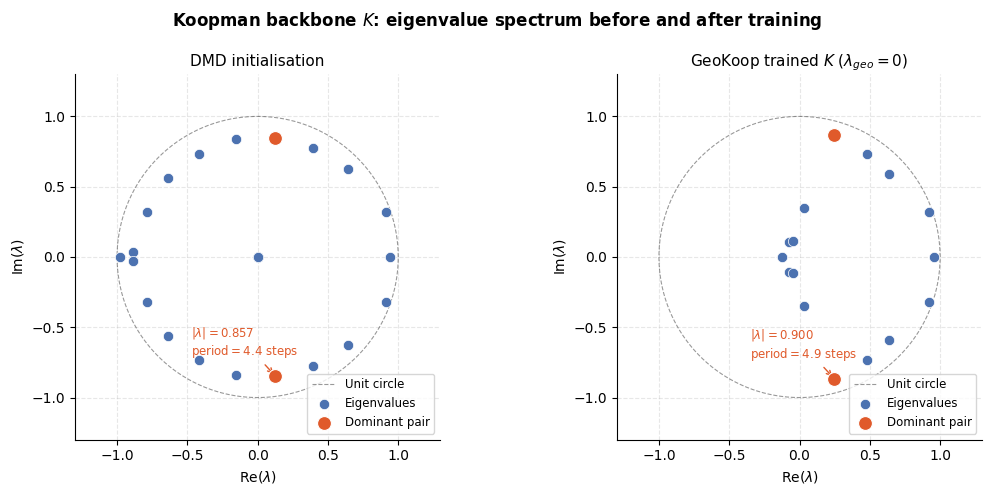

Saved figure_eigenvalues.png


In [30]:
# ── Eigenvalue analysis: K before and after training ──────────────
# Option B interpretability: show trained K retains shedding frequency

import matplotlib

K_trained = koop_c_geo.K.detach().cpu().numpy()   # GeoKoop trained K
eigs_K    = np.linalg.eigvals(K_trained)
eigs_dmd  = np.linalg.eigvals(A_dmd_c)

# Sort by magnitude descending
eigs_K   = eigs_K[np.argsort(-np.abs(eigs_K))]
eigs_dmd = eigs_dmd[np.argsort(-np.abs(eigs_dmd))]

print('=' * 65)
print(f'{"":30s}  {"|λ|":>10s}  {"angle (rad)":>12s}  {"period":>8s}')
print('=' * 65)
print('DMD K (before training):')
for i, ev in enumerate(eigs_dmd[:6]):
    mag = np.abs(ev)
    angle = np.abs(np.angle(ev))
    period = 2*np.pi/angle if angle > 1e-6 else np.inf
    print(f'  lambda_{i+1}  {mag:>10.4f}  {angle:>12.4f}  {period:>8.2f}')
print()
print('GeoKoop trained K (unregularised, lam_geo=0):')
for i, ev in enumerate(eigs_K[:6]):
    mag = np.abs(ev)
    angle = np.abs(np.angle(ev))
    period = 2*np.pi/angle if angle > 1e-6 else np.inf
    print(f'  lambda_{i+1}  {mag:>10.4f}  {angle:>12.4f}  {period:>8.2f}')
print()

# ── Figure: eigenvalues on unit circle ────────────────────────────
theta = np.linspace(0, 2*np.pi, 300)
fig, axes = plt.subplots(1, 2, figsize=(11, 5))
fig.suptitle(
    'Koopman backbone $K$: eigenvalue spectrum before and after training',
    fontsize=12, fontweight='bold')

for ax, eigs, title in zip(
        axes,
        [eigs_dmd, eigs_K],
        ['DMD initialisation', 'GeoKoop trained $K$ ($\\lambda_{geo}=0$)']):
    ax.plot(np.cos(theta), np.sin(theta), 'k--', lw=0.8, alpha=0.4,
            label='Unit circle')
    ax.scatter(eigs.real, eigs.imag,
               c='#4C72B0', s=55, zorder=4, edgecolors='white',
               linewidth=0.5, label='Eigenvalues')
    # Highlight dominant complex conjugate pair (largest |imag|)
    dom_idx = np.argmax(np.abs(eigs.imag))
    dom = eigs[dom_idx]
    conj = eigs[np.argmin(np.abs(eigs - dom.conj()))]
    ax.scatter([dom.real, conj.real], [dom.imag, conj.imag],
               c='#E05A2B', s=100, zorder=5, edgecolors='white',
               linewidth=0.8, label='Dominant pair')
    angle = np.abs(np.angle(dom))
    period = 2*np.pi/angle if angle > 1e-6 else np.inf
    ax.annotate(
        f'$|\\lambda|={np.abs(dom):.3f}$\nperiod$={period:.1f}$ steps',
        xy=(dom.real, dom.imag),
        xytext=(dom.real - 0.6, dom.imag + 0.15),
        fontsize=8.5, color='#E05A2B',
        arrowprops=dict(arrowstyle='->', color='#E05A2B', lw=1.0))
    ax.set_xlim(-1.3, 1.3); ax.set_ylim(-1.3, 1.3)
    ax.set_aspect('equal')
    ax.set_xlabel('Re($\\lambda$)', fontsize=10)
    ax.set_ylabel('Im($\\lambda$)', fontsize=10)
    ax.set_title(title, fontsize=11)
    ax.legend(fontsize=8.5, loc='lower right')
    ax.grid(True, linestyle='--', alpha=0.3)
    ax.spines[['top', 'right']].set_visible(False)

plt.tight_layout()
out = 'figure_eigenvalues.png'
plt.savefig(out, dpi=150, bbox_inches='tight')
shutil.copy(out, f'{OUTPUT_DIR}/figure_eigenvalues.png')
plt.show()
print(f'Saved {out}')


In [31]:
# ── Table 3: Four-model comparison — 5 seeds ────────────────────────
# Pendulum · FluidFlowBox · Cylinder
# Uses system-specific functions — no is_bb kwarg issue.

import numpy as np, torch
N_SEEDS = 5

# ════════════════════════════════════
# 1. PENDULUM — 5 seeds
# ════════════════════════════════════
res_p = {k: [] for k in ['dmd','bb','base','geo']}
for seed in range(N_SEEDS):
    torch.manual_seed(seed); np.random.seed(seed)
    if torch.cuda.is_available(): torch.cuda.manual_seed_all(seed)

    ae_b = AE(2, P_LATENT, hidden=64).to(device)
    bb_s = BlackBoxNN(P_LATENT, hidden=32).to(device)
    train_pendulum(ae_b, bb_s, f'Pend-BB-s{seed}', use_geo=False, is_bb=True)

    ae_s = AE(2, P_LATENT, hidden=64).to(device)
    kp_s = KoopmanPendulum(d=P_LATENT, use_geo=False).to(device)
    train_pendulum(ae_s, kp_s, f'Pend-Base-s{seed}', use_geo=False)

    ae_g = AE(2, P_LATENT, hidden=64).to(device)
    kg_s = KoopmanPendulum(d=P_LATENT, use_geo=True).to(device)
    train_pendulum(ae_g, kg_s, f'Pend-Geo-s{seed}', use_geo=True)

    res_p['dmd'].append(pend_dmd_rollout_err(X_te_n)[-1])
    res_p['bb'].append(pend_rollout_err(ae_b, bb_s, X_te_n)[-1])
    res_p['base'].append(pend_rollout_err(ae_s, kp_s, X_te_n)[-1])
    res_p['geo'].append(pend_rollout_err(ae_g, kg_s, X_te_n)[-1])
    print(f'Pend s{seed}: DMD={res_p["dmd"][-1]:.4f}  BB={res_p["bb"][-1]:.4f}  '
          f'Base={res_p["base"][-1]:.4f}  Geo={res_p["geo"][-1]:.4f}')

print(f"\nPendulum 5-seed: "
      f"Geo={np.mean(res_p['geo']):.4f}±{np.std(res_p['geo'],ddof=1):.4f}  "
      f"vs DK={np.mean(res_p['base'])/np.mean(res_p['geo']):.1f}x  "
      f"vs BB={np.mean(res_p['bb'])/np.mean(res_p['geo']):.2f}x\n")

# ════════════════════════════════════
# 2. FLUIDFLOWBOX — 5 seeds
#    KEY FIX: save CPU copy of f_xtp1 BEFORE training moves it to GPU
# ════════════════════════════════════
res_f = {k: [] for k in ['dmd','bb','base','geo']}

# Save CPU copy now — train_model/train_blackbox call .to(device) internally
# which moves the original tensor to GPU, breaking later CPU comparisons
f_xtp1_cpu = f_xtp1.cpu().clone()
f_xt_cpu   = f_xt.cpu().clone()
print(f'Saved CPU copies: f_xt_cpu={f_xt_cpu.device}  f_xtp1_cpu={f_xtp1_cpu.device}')

def fluid_err_at49(ae, dyn):
    """Rollout 49 steps from first training point, return error at step 49."""
    ae.eval(); dyn.eval()
    with torch.no_grad():
        z     = ae.encode(f_xt_cpu[:1].to(device))
        for k in range(49):
            z = dyn(z)
        x_hat  = ae.decode(z).cpu()
        target = f_xtp1_cpu[48:49]   # guaranteed CPU
    return (x_hat - target).norm().item()

for seed in range(N_SEEDS):
    torch.manual_seed(seed); np.random.seed(seed)
    if torch.cuda.is_available(): torch.cuda.manual_seed_all(seed)

    # ── Black-box ──────────────────────────────────────────────────
    ae_b = AE(3, F_LATENT, hidden=128).to(device)
    bb_s = BlackBoxNN(F_LATENT, hidden=64).to(device)
    train_blackbox(ae_b, bb_s, f_xt, f_xtp1,
                   label=f'Fluid-BB-s{seed}',
                   epochs_p1=1000, epochs_p2=2000)

    # ── Deep Koopman ───────────────────────────────────────────────
    ae_s = AE(3, F_LATENT, hidden=128).to(device)
    kf_s = KoopmanCore(F_LATENT, use_geo=False).to(device)
    train_model(ae_s, kf_s, f_xt, f_xtp1, use_geo=False,
                label=f'Fluid-Base-s{seed}',
                epochs_p1=1000, epochs_p2=2000, lam_geo=0.0)

    # ── GeoKoop ────────────────────────────────────────────────────
    ae_g = AE(3, F_LATENT, hidden=128).to(device)
    kg_s = KoopmanCore(F_LATENT, use_geo=True).to(device)
    train_model(ae_g, kg_s, f_xt, f_xtp1, use_geo=True,
                label=f'Fluid-Geo-s{seed}',
                epochs_p1=1000, epochs_p2=2000, lam_geo=0.0)

    res_f['dmd'].append(err_f_dmd[-1])
    res_f['bb'].append(fluid_err_at49(ae_b, bb_s))
    res_f['base'].append(fluid_err_at49(ae_s, kf_s))
    res_f['geo'].append(fluid_err_at49(ae_g, kg_s))
    print(f'Fluid s{seed}: DMD={res_f["dmd"][-1]:.4f}  BB={res_f["bb"][-1]:.4f}  '
          f'Base={res_f["base"][-1]:.4f}  Geo={res_f["geo"][-1]:.4f}')

print(f"\nFluidFlowBox 5-seed: "
      f"Geo={np.mean(res_f['geo']):.4f}±{np.std(res_f['geo'],ddof=1):.4f}  "
      f"vs DK={np.mean(res_f['base'])/np.mean(res_f['geo']):.2f}x  "
      f"vs BB={np.mean(res_f['bb'])/np.mean(res_f['geo']):.2f}x\n")

# ════════════════════════════════════
# 3. CYLINDER — 5 seeds
# ════════════════════════════════════

# ── Safety: recompute A_dmd_c_orig if session restarted ──────────
if 'A_dmd_c_orig' not in dir():
    print('A_dmd_c_orig not found — recomputing from cx_t/cx_tp1...')
    assert 'cx_t' in dir(), "Run Cell 19 (cylinder load) first"
    X_c   = cx_t.cpu().numpy().T
    Xp_c  = cx_tp1.cpu().numpy().T
    U, S, Vt = np.linalg.svd(X_c, full_matrices=False)
    r_use = min(C_LATENT, len(S))
    A_dmd_c = (Xp_c @ Vt[:r_use].T
               @ np.diag(1.0/S[:r_use])
               @ U[:, :r_use].T)
    A_dmd_c_orig = np.array(A_dmd_c, dtype=np.float64)
    print(f'  Recomputed. shape={A_dmd_c_orig.shape}')
else:
    print(f'A_dmd_c_orig in scope. shape={A_dmd_c_orig.shape}')

res_c = {k: [] for k in ['dmd','bb','base','geo']}
for seed in range(N_SEEDS):
    torch.manual_seed(seed); np.random.seed(seed)
    if torch.cuda.is_available(): torch.cuda.manual_seed_all(seed)
    A_dmd_c = np.array(A_dmd_c_orig, dtype=np.float64)  # restore each seed

    ae_s, koop_s = cyl_ae(C_LATENT), cyl_koop(C_LATENT, geo=False)
    train_model(ae_s, koop_s, cx_t, cx_tp1, use_geo=False,
                label=f'Cyl-Base-s{seed}',
                epochs_p1=500, epochs_p2=3000, lam_geo=0.0)

    ae_g, koop_g = cyl_ae(C_LATENT), cyl_koop(C_LATENT, geo=True)
    train_model(ae_g, koop_g, cx_t, cx_tp1, use_geo=True,
                label=f'Cyl-Geo-s{seed}',
                epochs_p1=500, epochs_p2=3000, lam_geo=0.0)

    ae_b = cyl_ae(C_LATENT)
    bb_s = BlackBoxNN(C_LATENT, hidden=64).to(device)
    train_blackbox(ae_b, bb_s, cx_t, cx_tp1, label=f'Cyl-BB-s{seed}')

    X_base_s = cyl_rollout(ae_s, koop_s)
    X_geo_s  = cyl_rollout(ae_g, koop_g)
    X_bb_s   = cyl_rollout(ae_b, bb_s)

    res_c['dmd'].append(err_c_dmd[100:].mean())
    res_c['base'].append(np.linalg.norm(vort_all-X_base_s, axis=0)[100:].mean())
    res_c['geo'].append(np.linalg.norm(vort_all-X_geo_s,  axis=0)[100:].mean())
    res_c['bb'].append(np.linalg.norm(vort_all-X_bb_s,   axis=0)[100:].mean())
    print(f'Cyl s{seed}: DMD={res_c["dmd"][-1]:.3f}  BB={res_c["bb"][-1]:.3f}  '
          f'Base={res_c["base"][-1]:.3f}  Geo={res_c["geo"][-1]:.3f}')

print(f"\nCylinder 5-seed: "
      f"Geo={np.mean(res_c['geo']):.3f}±{np.std(res_c['geo'],ddof=1):.3f}  "
      f"vs DK={np.mean(res_c['base'])/np.mean(res_c['geo']):.1f}x  "
      f"vs BB={np.mean(res_c['bb'])/np.mean(res_c['geo']):.2f}x\n")

# ════════════════════════════════════
# FINAL TABLE 3 PRINTOUT
# ════════════════════════════════════
print()
print("=" * 90)
print("TABLE 3: FOUR-MODEL COMPARISON  (5 seeds, mean ± std)")
print("=" * 90)
print(f"  {'System':<24} {'DMD':>8} {'Black-box':>14} {'Deep K.':>14} "
      f"{'GeoKoop':>14} {'vsDK':>7} {'vsBB':>7}")
print("-" * 90)
for label, res in [('Pendulum (@49)',      res_p),
                   ('FluidFlowBox (@49)',  res_f),
                   ('Cylinder (t=100-150)',res_c)]:
    gm = np.mean(res['geo'])
    bm = np.mean(res['base'])
    bbm= np.mean(res['bb'])
    print(f"  {label:<24} "
          f"{np.mean(res['dmd']):>8.3f} "
          f"{bbm:>8.3f}±{np.std(res['bb'],ddof=1):.3f} "
          f"{bm:>8.3f}±{np.std(res['base'],ddof=1):.3f} "
          f"{gm:>8.3f}±{np.std(res['geo'],ddof=1):.3f} "
          f"{bm/gm:>6.1f}x "
          f"{bbm/gm:>6.2f}x")
print("=" * 90)
print()
print("Notes:")
print("  vs DK: Deep Koopman / GeoKoop  (>1 means GeoKoop wins)")
print("  vs BB: Black-box / GeoKoop     (>1 means GeoKoop wins)")
print()
table3_results = {'pendulum': res_p, 'fluidflowbox': res_f, 'cylinder': res_c}
print("Copy numbers above into Table 3 of the paper.")

[Pend-BB-s0] ep=   0 | rec=1.00564 dyn=0.06836 roll=0.00000
[Pend-BB-s0] ep= 500 | rec=0.00013 dyn=0.00028 roll=0.00000
[Pend-BB-s0] ep=1000 | rec=0.00006 dyn=0.00009 roll=0.00581
[Pend-BB-s0] ep=1500 | rec=0.00004 dyn=0.00002 roll=0.00031
[Pend-BB-s0] ep=2000 | rec=0.00003 dyn=0.00000 roll=0.00007
[Pend-BB-s0] ep=2500 | rec=0.00002 dyn=0.00000 roll=0.00006
[Pend-Base-s0] ep=   0 | rec=0.98849 dyn=0.00001 roll=0.00000
[Pend-Base-s0] ep= 500 | rec=0.00012 dyn=0.00001 roll=0.00000
[Pend-Base-s0] ep=1000 | rec=0.00005 dyn=0.00001 roll=0.00076
[Pend-Base-s0] ep=1500 | rec=0.00003 dyn=0.00000 roll=0.00066
[Pend-Base-s0] ep=2000 | rec=0.00002 dyn=0.00000 roll=0.00061
[Pend-Base-s0] ep=2500 | rec=0.00002 dyn=0.00000 roll=0.00059
[Pend-Geo-s0] ep=   0 | rec=0.99388 dyn=0.00002 roll=0.00000
[Pend-Geo-s0] ep= 500 | rec=0.00010 dyn=0.00000 roll=0.00000
[Pend-Geo-s0] ep=1000 | rec=0.00006 dyn=0.00000 roll=0.00001
[Pend-Geo-s0] ep=1500 | rec=0.00003 dyn=0.00000 roll=0.00001
[Pend-Geo-s0] ep=2000 | 

TypeError: empty(): argument 'size' failed to unpack the object at pos 2 with error "type must be tuple of ints,but got float"

In [33]:
# ════════════════════════════════════
# 3. CYLINDER — 5 seeds   (r-bug fixed + resumable)
# ════════════════════════════════════
import os, json

# ── Safety: recompute A_dmd_c_orig if session restarted ──────────
if 'A_dmd_c_orig' not in dir():
    print('A_dmd_c_orig not found — recomputing from cx_t/cx_tp1...')
    assert 'cx_t' in dir(), "Run the cylinder-load cell first"
    X_c   = cx_t.cpu().numpy().T
    Xp_c  = cx_tp1.cpu().numpy().T
    U, S, Vt = np.linalg.svd(X_c, full_matrices=False)
    r_use = min(C_LATENT, len(S))
    A_dmd_c = (Xp_c @ Vt[:r_use].T @ np.diag(1.0/S[:r_use]) @ U[:, :r_use].T)
    A_dmd_c_orig = np.array(A_dmd_c, dtype=np.float64)
    print(f'  Recomputed. shape={A_dmd_c_orig.shape}')
else:
    print(f'A_dmd_c_orig in scope. shape={A_dmd_c_orig.shape}')

# ── THE FIX ──────────────────────────────────────────────────────
# An earlier cell (Van der Pol: `r = np.random.uniform(0.5, 2.5)`)
# overwrites the global `r` that cyl_ae/cyl_koop depend on, leaving it a
# float -> "TypeError: ... got a float" when building the cylinder model.
# Derive r straight from the cylinder data so it can't be clobbered again.
r = cx_t.shape[1]            # = 32, the POD-mode count the cylinder AE expects
print(f'  Cylinder POD dim restored: r = {r}')
# (KoopmanCore slices K_init[:C_LATENT,:C_LATENT] internally, so a 32x32
#  A_dmd_c_orig is fine — it uses the top-left 16x16 block.)

# ── Resumable checkpoint (cylinder is the slow part that keeps dying) ──
CKPT_CYL = f"{OUTPUT_DIR}/table3_cylinder_checkpoint.json"
def _load_cyl():
    if os.path.exists(CKPT_CYL):
        with open(CKPT_CYL) as f: return json.load(f)
    return {}
def _save_cyl(d):
    tmp = CKPT_CYL + ".tmp"
    with open(tmp, "w") as f: json.dump(d, f, indent=2)
    os.replace(tmp, CKPT_CYL)     # atomic write
cyl_ckpt = _load_cyl()

for seed in range(N_SEEDS):
    if str(seed) in cyl_ckpt:
        print(f'Cyl s{seed}: already done — skipping'); continue
    torch.manual_seed(seed); np.random.seed(seed)
    if torch.cuda.is_available(): torch.cuda.manual_seed_all(seed)
    A_dmd_c = np.array(A_dmd_c_orig, dtype=np.float64)  # restore each seed

    ae_s, koop_s = cyl_ae(C_LATENT), cyl_koop(C_LATENT, geo=False)
    train_model(ae_s, koop_s, cx_t, cx_tp1, use_geo=False,
                label=f'Cyl-Base-s{seed}',
                epochs_p1=500, epochs_p2=3000, lam_geo=0.0)

    ae_g, koop_g = cyl_ae(C_LATENT), cyl_koop(C_LATENT, geo=True)
    train_model(ae_g, koop_g, cx_t, cx_tp1, use_geo=True,
                label=f'Cyl-Geo-s{seed}',
                epochs_p1=500, epochs_p2=3000, lam_geo=0.0)

    ae_b = cyl_ae(C_LATENT)
    bb_s = BlackBoxNN(C_LATENT, hidden=64).to(device)
    train_blackbox(ae_b, bb_s, cx_t, cx_tp1, label=f'Cyl-BB-s{seed}')

    X_base_s = cyl_rollout(ae_s, koop_s)
    X_geo_s  = cyl_rollout(ae_g, koop_g)
    X_bb_s   = cyl_rollout(ae_b, bb_s)

    rec = {'dmd':  float(err_c_dmd[100:].mean()),
           'base': float(np.linalg.norm(vort_all - X_base_s, axis=0)[100:].mean()),
           'geo':  float(np.linalg.norm(vort_all - X_geo_s,  axis=0)[100:].mean()),
           'bb':   float(np.linalg.norm(vort_all - X_bb_s,   axis=0)[100:].mean())}
    cyl_ckpt[str(seed)] = rec
    _save_cyl(cyl_ckpt)
    print(f'Cyl s{seed}: DMD={rec["dmd"]:.3f}  BB={rec["bb"]:.3f}  '
          f'Base={rec["base"]:.3f}  Geo={rec["geo"]:.3f}   [checkpoint saved]')

# rebuild res_c from the checkpoint (seed order) so the final Table-3 printout works
res_c = {k: [cyl_ckpt[str(s)][k] for s in range(N_SEEDS) if str(s) in cyl_ckpt]
         for k in ['dmd', 'bb', 'base', 'geo']}

if len(res_c['geo']) == N_SEEDS:
    print(f"\nCylinder 5-seed: "
          f"Geo={np.mean(res_c['geo']):.3f}±{np.std(res_c['geo'],ddof=1):.3f}  "
          f"vs DK={np.mean(res_c['base'])/np.mean(res_c['geo']):.1f}x  "
          f"vs BB={np.mean(res_c['bb'])/np.mean(res_c['geo']):.2f}x\n")
else:
    print(f"\nCylinder: {len(res_c['geo'])}/{N_SEEDS} seeds done — "
          f"re-run this cell to continue from where it stopped.\n")

A_dmd_c_orig in scope. shape=(32, 32)
  Cylinder POD dim restored: r = 32
[Cyl-Base-s0]    0 | rec=1.00584 dyn=0.03244 roll=0.00000 geo=0.0000
[Cyl-Base-s0]  200 | rec=0.06733 dyn=0.35790 roll=0.00000 geo=0.0000
[Cyl-Base-s0]  400 | rec=0.00101 dyn=0.07901 roll=0.00000 geo=0.0000
[Cyl-Base-s0]  600 | rec=0.00146 dyn=0.01605 roll=0.07055 geo=0.0000
[Cyl-Base-s0]  800 | rec=0.00057 dyn=0.00737 roll=0.03952 geo=0.0000
[Cyl-Base-s0] 1000 | rec=0.00080 dyn=0.00483 roll=0.02914 geo=0.0000
[Cyl-Base-s0] 1200 | rec=0.00027 dyn=0.00407 roll=0.02598 geo=0.0000
[Cyl-Base-s0] 1400 | rec=0.00023 dyn=0.00346 roll=0.02333 geo=0.0000
[Cyl-Base-s0] 1600 | rec=0.00021 dyn=0.00296 roll=0.02110 geo=0.0000
[Cyl-Base-s0] 1800 | rec=0.00019 dyn=0.00257 roll=0.01924 geo=0.0000
[Cyl-Base-s0] 2000 | rec=0.00020 dyn=0.00225 roll=0.01768 geo=0.0000
[Cyl-Base-s0] 2200 | rec=0.00014 dyn=0.00211 roll=0.01697 geo=0.0000
[Cyl-Base-s0] 2400 | rec=0.00013 dyn=0.00197 roll=0.01626 geo=0.0000
[Cyl-Base-s0] 2600 | rec=0.00


TABLE 4: MECHANISM TEST — N(z_t) ≈ J_f(z_t) - K
Element-wise Pearson r between learned N(z) and J_f(z)-K
  System                              d  Type           mean r    std r      n
----------------------------------------------------------------------
  Pendulum                            4  ODE, periodic    0.8200   0.1799    200  **STRONG**
  Van der Pol                         4  ODE, limit cyc    0.9583   0.0042    200  **STRONG**
  Lorenz                              6  ODE, chaotic    0.9642   0.0044    200  **STRONG**
  Cylinder (vortex shed.)            16  PDE, periodic    0.9217   0.0177    100  **STRONG**
  Kuramoto-Sivashinsky                8  PDE, chaotic    0.9373   0.0356    150  **STRONG**

Interpretation: r > 0.7 = STRONG support for N(z) ≈ J_f(z)-K
                r > 0.4 = MODERATE support
                r < 0.2 = WEAK (mechanism not confirmed)



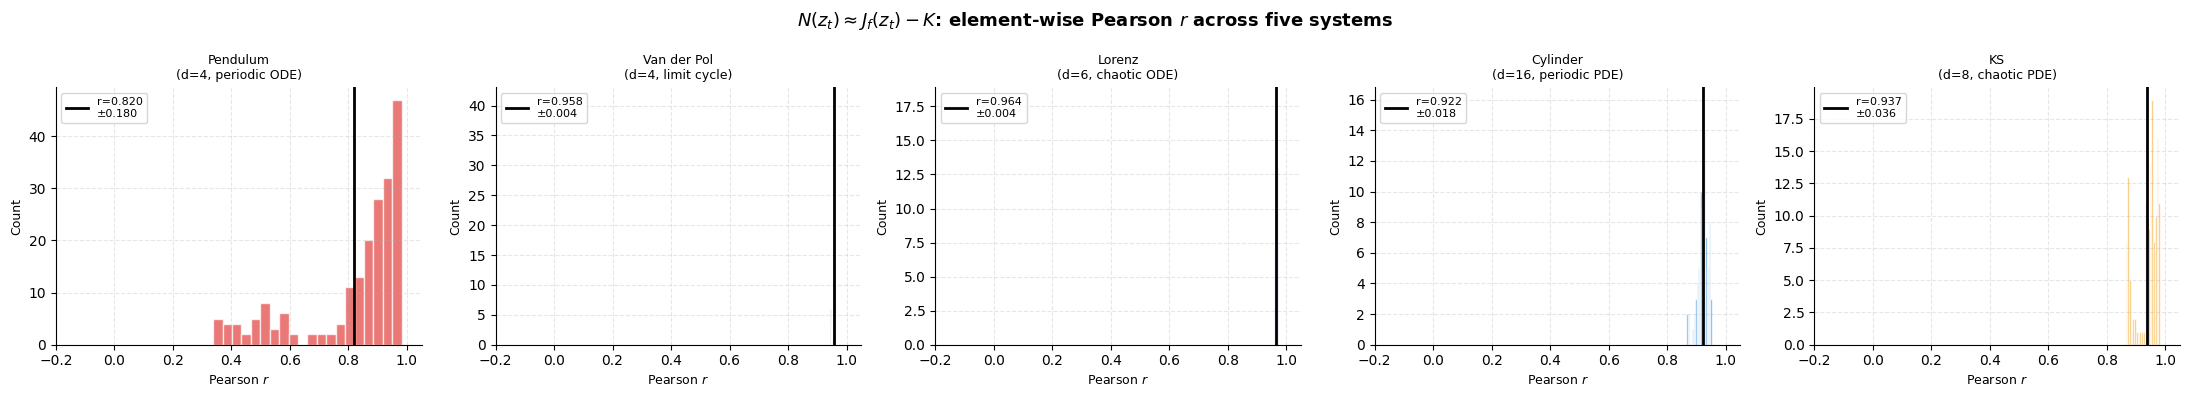

Saved mechanism_summary.png

Ready to update paper:
  Table 3 → copy numbers from TABLE 3 output above
  Table 4 → copy mean r and std r from TABLE 4 output above


In [32]:
# ── Table 4: Mechanism test summary — N(z) ≈ J_f(z) - K ────────────
print()
print("=" * 70)
print("TABLE 4: MECHANISM TEST — N(z_t) ≈ J_f(z_t) - K")
print("Element-wise Pearson r between learned N(z) and J_f(z)-K")
print("=" * 70)
print(f"  {'System':<32} {'d':>4}  {'Type':<12} {'mean r':>8}  {'std r':>7}  {'n':>5}")
print("-" * 70)

all_results = [
    ("mech_pend",   "Pendulum",               P_LATENT,   "ODE, periodic"),
    ("mech_vdp",    "Van der Pol",             VDP_LATENT, "ODE, limit cyc"),
    ("mech_lorenz", "Lorenz",                  LZ_LATENT,  "ODE, chaotic"),
    ("mech_cyl",    "Cylinder (vortex shed.)", C_LATENT,   "PDE, periodic"),
    ("mech_ks",     "Kuramoto-Sivashinsky",    KS_LATENT,  "PDE, chaotic"),
]

stored = {
    "mech_pend":   mech_pend   if "mech_pend"   in dir() else None,
    "mech_vdp":    mech_vdp    if "mech_vdp"    in dir() else None,
    "mech_lorenz": mech_lorenz if "mech_lorenz" in dir() else None,
    "mech_cyl":    mech_cyl    if "mech_cyl"    in dir() else None,
    "mech_ks":     mech_ks     if "mech_ks"     in dir() else None,
}

for key, label, d, stype in all_results:
    res = stored[key]
    if res is None:
        print(f"  {label:<32} {d:>4}  {stype:<12}  {'not run':>8}")
        continue
    r = res["correlations"]
    verdict = ("**STRONG**" if r.mean() > 0.7 else
               "MODERATE"   if r.mean() > 0.4 else "weak")
    print(f"  {label:<32} {d:>4}  {stype:<12}  "
          f"{r.mean():>8.4f}  {r.std():>7.4f}  {len(r):>5}  {verdict}")

print("=" * 70)
print()
print("Interpretation: r > 0.7 = STRONG support for N(z) ≈ J_f(z)-K")
print("                r > 0.4 = MODERATE support")
print("                r < 0.2 = WEAK (mechanism not confirmed)")
print()

# ── Combined 5-panel figure ──────────────────────────────────────
fig, axes = plt.subplots(1, 5, figsize=(22, 4))
fig.suptitle(
    r"$N(z_t) \approx J_f(z_t)-K$: element-wise Pearson $r$ across five systems",
    fontsize=13, fontweight='bold')

panel_info = [
    ("mech_pend",   f"Pendulum\n(d={P_LATENT}, periodic ODE)",    COLORS['GeoKoop']),
    ("mech_vdp",    f"Van der Pol\n(d={VDP_LATENT}, limit cycle)", COLORS['DMD']),
    ("mech_lorenz", f"Lorenz\n(d={LZ_LATENT}, chaotic ODE)",      '#9B59B6'),
    ("mech_cyl",    f"Cylinder\n(d={C_LATENT}, periodic PDE)",     COLORS['Baseline']),
    ("mech_ks",     f"KS\n(d={KS_LATENT}, chaotic PDE)",           COLORS['BlackBox']),
]

for ax, (key, label, color) in zip(axes, panel_info):
    res = stored[key]
    if res is None:
        ax.text(0.5, 0.5, "Not run", ha='center', va='center',
                transform=ax.transAxes, fontsize=11)
        ax.set_title(label, fontsize=9)
        continue
    r = res["correlations"]
    ax.hist(r, bins=20, color=color, alpha=0.75, edgecolor='white')
    ax.axvline(r.mean(), color='k', lw=2,
               label=f'r={r.mean():.3f}\n±{r.std():.3f}')
    ax.set_xlim(-0.2, 1.05)
    ax.set_xlabel("Pearson $r$", fontsize=9)
    ax.set_ylabel("Count", fontsize=9)
    ax.set_title(label, fontsize=9)
    ax.legend(fontsize=8, loc='upper left')
    ax.grid(True, linestyle='--', alpha=0.3)
    ax.spines[['top','right']].set_visible(False)

plt.tight_layout()
for fname in ['mechanism_summary.png',
              f'{OUTPUT_DIR}/mechanism_summary.png',
              f'{FIG_DIR}/mechanism_summary.png']:
    plt.savefig(fname, dpi=150, bbox_inches='tight')
plt.show()
print("Saved mechanism_summary.png")
print()
print("Ready to update paper:")
print("  Table 3 → copy numbers from TABLE 3 output above")
print("  Table 4 → copy mean r and std r from TABLE 4 output above")
